# --- 1. CONFIGURACIÓN E IMPORTACIÓN DE LIBRERÍAS ---

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

print("--- Iniciando el análisis exploratorio del dataset de ECG ---")

--- Iniciando el análisis exploratorio del dataset de ECG ---


# --- 2. CARGA E INSPECCIÓN INICIAL DE LOS DATOS ---
# Carga el archivo CSV en un DataFrame de pandas.
# Asegúrate de que '12large_meta.csv' esté en el mismo directorio.

In [17]:
try:
    df = pd.read_csv('metadast.csv')
    print("\n[PASO 1/4] Archivo CSV cargado exitosamente.")
except FileNotFoundError:
    print("\n[ERROR] No se encontró el archivo '12large_meta.csv'.")
    print("Por favor, asegúrate de que el archivo esté en el mismo directorio que este script.")
    exit()

# Muestra las primeras 5 filas para tener una idea de la estructura.
print("\n--- Primeras 5 filas del dataset ---")
print(df.head())

# Muestra información general: columnas, tipos de datos y valores no nulos.
print("\n--- Información general del DataFrame ---")
df.info()

# Muestra estadísticas descriptivas para las columnas numéricas.
print("\n--- Estadísticas descriptivas ---")
print(df.describe())


[PASO 1/4] Archivo CSV cargado exitosamente.

--- Primeras 5 filas del dataset ---
             hea_path  mat_exists patient_id   age sex  num_leads     fs  \
0  01/010/JS00001.hea        True    JS00001  85.0   M         12  500.0   
1  01/010/JS00002.hea        True    JS00002  59.0   F         12  500.0   
2  01/010/JS00004.hea        True    JS00004  66.0   M         12  500.0   
3  01/010/JS00005.hea        True    JS00005  73.0   F         12  500.0   
4  01/010/JS00006.hea        True    JS00006  46.0   F         12  500.0   

   num_samples  num_labels                         labels  
0       5000.0           3   164889003,59118001,164934002  
1       5000.0           2            426177001,164934002  
2       5000.0           1                      426177001  
3       5000.0           3  164890007,429622005,428750005  
4       5000.0           1                      426177001  

--- Información general del DataFrame ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43657 

# --- 3. LIMPIEZA DE DATOS (DATA WRANGLING) ---

In [18]:
print("\n[PASO 2/4] Realizando limpieza y validación de datos...")

# Verificar si hay valores nulos en alguna columna.
missing_values = df.isnull().sum()
print("\n--- Conteo de valores nulos por columna ---")
print(missing_values)
if missing_values.sum() == 0:
    print("¡Excelente! No hay valores nulos en el dataset.")
else:
    print("Se encontraron valores nulos. Se recomienda tratarlos (eliminar o imputar).")

# Verificar si hay filas duplicadas.
duplicate_rows = df.duplicated().sum()
print(f"\n--- Número de filas duplicadas: {duplicate_rows} ---")
if duplicate_rows == 0:
    print("No se encontraron filas duplicadas.")
else:
    # Si se encuentran duplicados, se pueden eliminar con:
    # df = df.drop_duplicates()
    pass

# Verificar la consistencia de los datos.
# Por la descripción del dataset, esperamos que la mayoría de los ECGs
# tengan 12 derivaciones (leads) y una frecuencia de muestreo (fs) de 500 Hz.
print("\n--- Conteo de valores únicos en 'num_leads' ---")
print(df['num_leads'].value_counts())

print("\n--- Conteo de valores únicos en 'fs' (frecuencia de muestreo) ---")
print(df['fs'].value_counts())




[PASO 2/4] Realizando limpieza y validación de datos...

--- Conteo de valores nulos por columna ---
hea_path        0
mat_exists      0
patient_id      0
age            55
sex            22
num_leads       0
fs              0
num_samples     1
num_labels      0
labels          0
dtype: int64
Se encontraron valores nulos. Se recomienda tratarlos (eliminar o imputar).

--- Número de filas duplicadas: 0 ---
No se encontraron filas duplicadas.

--- Conteo de valores únicos en 'num_leads' ---
num_leads
12    43657
Name: count, dtype: int64

--- Conteo de valores únicos en 'fs' (frecuencia de muestreo) ---
fs
500.0    43657
Name: count, dtype: int64



# --- 4. ANÁLISIS EXPLORATORIO DE DATOS (EDA) Y VISUALIZACIÓN ---


[PASO 3/4] Creando visualizaciones para el análisis...

Gráfico 'distribucion_etiquetas.png' guardado.


C:\Users\pevv2\AppData\Local\Temp\ipykernel_24200\3292618769.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Label', data=df_label_counts.head(top_n), palette='viridis')


Gráfico 'top_20_diagnosticos.png' guardado.

[PASO 4/4] Análisis finalizado.
Se han guardado dos gráficos en el directorio: 'distribucion_etiquetas.png' y 'top_20_diagnosticos.png'.


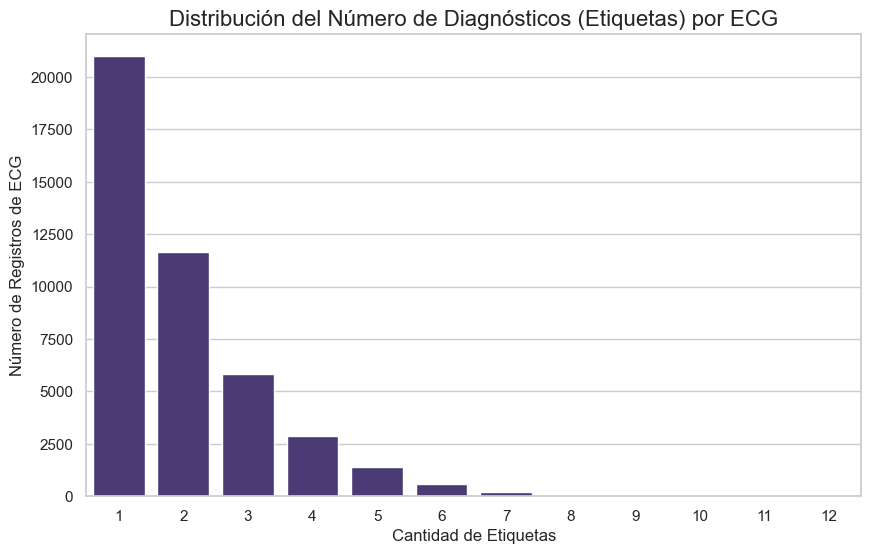

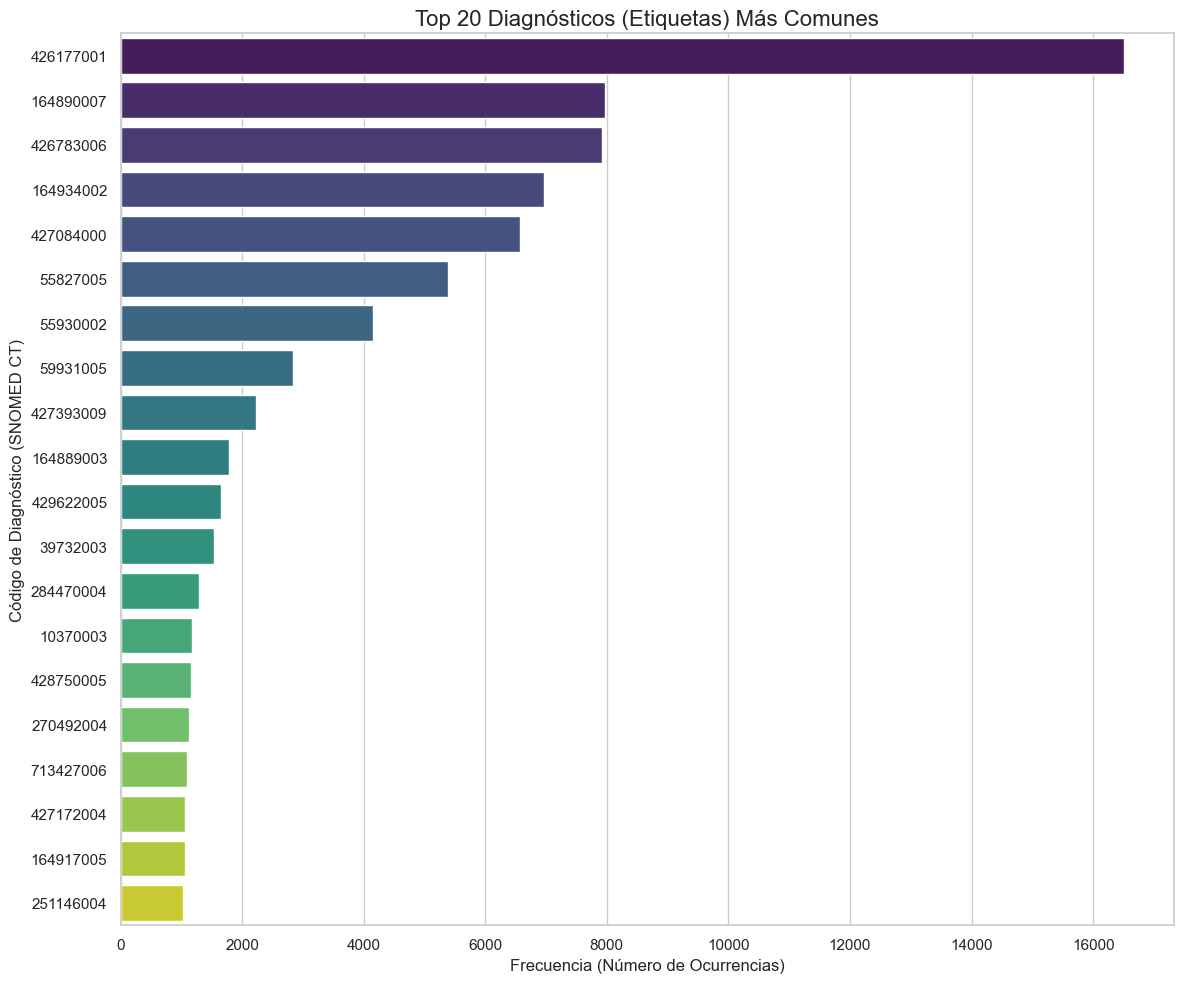

In [19]:
print("\n[PASO 3/4] Creando visualizaciones para el análisis...")

# Configuración del estilo de los gráficos.
sns.set(style="whitegrid", palette="viridis")

# 1. Distribución del número de etiquetas por registro de ECG
plt.figure(figsize=(10, 6))
sns.countplot(x='num_labels', data=df)
plt.title('Distribución del Número de Diagnósticos (Etiquetas) por ECG', fontsize=16)
plt.xlabel('Cantidad de Etiquetas', fontsize=12)
plt.ylabel('Número de Registros de ECG', fontsize=12)
plt.savefig('distribucion_etiquetas.png')
print("\nGráfico 'distribucion_etiquetas.png' guardado.")

# 2. Análisis de las etiquetas de diagnóstico (la parte más importante)
# La columna 'labels' es un string con códigos separados por comas.
# Necesitamos separar estos códigos para analizarlos individualmente.
# Primero, eliminamos filas donde las etiquetas puedan ser nulas (si las hubiera).
df_labels = df.dropna(subset=['labels'])

# Creamos una lista que contenga TODAS las etiquetas de todas las filas.
all_labels = []
for index, row in df_labels.iterrows():
    labels_list = str(row['labels']).split(',')
    all_labels.extend(labels_list)

# Contamos la frecuencia de cada etiqueta.
label_counts = Counter(all_labels)

# Convertimos el contador a un DataFrame para facilitar la visualización.
df_label_counts = pd.DataFrame(label_counts.items(), columns=['Label', 'Count'])
df_label_counts = df_label_counts.sort_values(by='Count', ascending=False)

# Visualizamos las 20 etiquetas más comunes.
top_n = 20
plt.figure(figsize=(12, 10))
sns.barplot(x='Count', y='Label', data=df_label_counts.head(top_n), palette='viridis')
plt.title(f'Top {top_n} Diagnósticos (Etiquetas) Más Comunes', fontsize=16)
plt.xlabel('Frecuencia (Número de Ocurrencias)', fontsize=12)
plt.ylabel('Código de Diagnóstico (SNOMED CT)', fontsize=12)
plt.tight_layout()
plt.savefig('top_20_diagnosticos.png')
print("Gráfico 'top_20_diagnosticos.png' guardado.")

print("\n[PASO 4/4] Análisis finalizado.")
print("Se han guardado dos gráficos en el directorio: 'distribucion_etiquetas.png' y 'top_20_diagnosticos.png'.")

# Mostrar los gráficos si estás en un entorno que lo permita (como Jupyter).
plt.show()

In [20]:
df_symbologia = pd.read_csv('C:\\Users\\pevv2\\OneDrive\\Documentos\\TESIS\\2_Modleo_AtencionPrimero\\datos\\12Large\\ConditionNames_SNOMED-CT.csv')

In [21]:
print(df_symbologia)

    Acronym Name                                          Full Name  Snomed_CT
0           1AVB                    1 degree atrioventricular block  270492004
1           2AVB                    2 degree atrioventricular block  195042002
2          2AVB1          2 degree atrioventricular block(Type one)   54016002
3          2AVB2          2 degree atrioventricular block(Type two)   28189009
4           3AVB                    3 degree atrioventricular block   27885002
..           ...                                                ...        ...
101        IRBBB  Electrocardiographic incomplete right bundle b...  713426002
102          BBB                     Bundle branch block (disorder)    6374002
103        APACE            Rhythm from artificial pacing (finding)   10370003
104         SVPB        Supraventricular premature beats (disorder)   63593006
105        BRADY           Electrocardiogram: bradycardia (finding)  426627000

[106 rows x 3 columns]


In [22]:
df

,hea_path,mat_exists,patient_id,age,sex,num_leads,fs,num_samples,num_labels,labels
0,01/010/JS00001.hea,True,JS00001,85.0,M,12,500.0,5000.0,3,"164889003,59118001,164934002"
1,01/010/JS00002.hea,True,JS00002,59.0,F,12,500.0,5000.0,2,"426177001,164934002"
2,01/010/JS00004.hea,True,JS00004,66.0,M,12,500.0,5000.0,1,426177001
3,01/010/JS00005.hea,True,JS00005,73.0,F,12,500.0,5000.0,3,"164890007,429622005,428750005"
4,01/010/JS00006.hea,True,JS00006,46.0,F,12,500.0,5000.0,1,426177001
...,...,...,...,...,...,...,...,...,...,...
43652,46/461/JS45546.hea,True,JS45546,37.0,M,12,500.0,5000.0,1,425856008
43653,46/461/JS45547.hea,True,JS45547,34.0,M,12,500.0,5000.0,1,425856008
43654,46/461/JS45548.hea,True,JS45548,41.0,F,12,500.0,5000.0,1,425856008
43655,46/461/JS45549.hea,True,JS45549,36.0,M,12,500.0,5000.0,1,425856008


In [23]:
df_symbologia.duplicated().count()

np.int64(106)

In [24]:
# Define macro mapping (using acronyms for simplicity; map to SNOMED if preferred)
macro_mapping = {
    'Normal/Sinus Rhythms': [
        'SR', 'SA', 'SAAWR', 'NSR'
    ],
    'Bradycardias': [
        'SB', 'BRADY'
    ],
    'Atrial Fibrillation/Flutter': [
        'AFIB', 'AF', 'AFL'
    ],
    'Supraventricular Tachyarrhythmias': [
        'SVT', 'AT', 'AVNRT', 'AVRT', 'ST'
    ],
    'Ventricular Arrhythmias': [
        'VB', 'VEB', 'VET', 'VPB', 'VPE', 'VFW', 'VT', 'VF', 'PVC'
    ],
    'Atrioventricular Blocks': [
        '1AVB', '2AVB', '2AVB1', '2AVB2', '3AVB', 'AVB'
    ],
    'Bundle Branch & Fascicular Blocks': [
        'LBBB', 'RBBB', 'IRBBB', 'CRBBB', 'LAnFB', 'LFBBB', 'BBB'
    ],
    'Axis Deviations & Rotations': [
        'LAD', 'RAD', 'ALS', 'ARS', 'CCR', 'CR'
    ],
    'Hypertrophy & High Voltage': [
        'LVH', 'RVH', 'RAH', 'LVHV', 'RAHV'
    ],
    'Myocardial Infarction': [
        'MI', 'MIBW', 'MIFW', 'MILW', 'MISW'
    ],
    'Wave Abnormalities': [
        'STDD', 'STE', 'STTC', 'STTU', 'TWC', 'TWO', 'AQW',
        'QAb', 'FQRS', 'ERV', 'PWC', 'UW', 'TAb', 'TInv', 'RW'
    ],
    'Interval Abnormalities': [
        'PRIE', 'QTIE', 'LQT', 'LPR', 'LRRI'
    ],
    'Low Voltage & Other Non-Specific': [
        'LVQRSAL', 'LVQRSCL', 'LVQRSLL', 'LVQ', 'LQRSV', 'NSIVCB', 'PRWP'
    ],
    'Ectopic Beats & Escape': [
        'ABI', 'APB', 'JEB', 'JPT', 'SPB', 'SVPB', 'PAC', 'VPB'
    ],
    'Pacing & Other': [
        'PR', 'WAVN', 'WPW', 'JPS', 'APACE'
    ]
}


# Function to assign macro class
def get_macro(acronym):
    for macro, micros in macro_mapping.items():
        if acronym in micros:
            return macro
    return 'Other/Unclassified'


In [25]:
import pandas as pd
df_ecg_exploded = df.copy()
df_ecg_exploded['labels'] = df_ecg_exploded['labels'].str.split(',')
df_ecg_exploded = df_ecg_exploded.explode('labels')
df_ecg_exploded['labels'] = df_ecg_exploded['labels'].str.strip().astype(str)  # Limpia espacios
df_symbologia['Snomed_CT'] = df_symbologia['Snomed_CT'].astype(str)

df_merged = pd.merge(df_ecg_exploded, df_symbologia, left_on='labels', right_on='Snomed_CT', how='left')

# Aplica el mapeo corregido
df_merged['macro_class'] = df_merged['Acronym Name'].apply(get_macro)


In [26]:
import numpy as np

In [27]:
df_merged

,hea_path,mat_exists,patient_id,age,sex,num_leads,fs,num_samples,num_labels,labels,Acronym Name,Full Name,Snomed_CT,macro_class
0,01/010/JS00001.hea,True,JS00001,85.0,M,12,500.0,5000.0,3,164889003,AFIB,Atrial Fibrillation,164889003,Atrial Fibrillation/Flutter
1,01/010/JS00001.hea,True,JS00001,85.0,M,12,500.0,5000.0,3,59118001,RBBB,right bundle branch block,59118001,Bundle Branch & Fascicular Blocks
2,01/010/JS00001.hea,True,JS00001,85.0,M,12,500.0,5000.0,3,164934002,TWC,T wave Change,164934002,Wave Abnormalities
3,01/010/JS00002.hea,True,JS00002,59.0,F,12,500.0,5000.0,2,426177001,SB,Sinus Bradycardia,426177001,Bradycardias
4,01/010/JS00002.hea,True,JS00002,59.0,F,12,500.0,5000.0,2,164934002,TWC,T wave Change,164934002,Wave Abnormalities
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87683,46/461/JS45547.hea,True,JS45547,34.0,M,12,500.0,5000.0,1,425856008,PVT,Electrocardiogram: paroxysmal ventricular tach...,425856008,Other/Unclassified
87684,46/461/JS45548.hea,True,JS45548,41.0,F,12,500.0,5000.0,1,425856008,PVT,Electrocardiogram: paroxysmal ventricular tach...,425856008,Other/Unclassified
87685,46/461/JS45549.hea,True,JS45549,36.0,M,12,500.0,5000.0,1,425856008,PVT,Electrocardiogram: paroxysmal ventricular tach...,425856008,Other/Unclassified
87686,46/461/JS45550.hea,True,JS45550,30.0,F,12,500.0,5000.0,2,233897008,AVRT,Atrioventricular Reentrant Tachycardia,233897008,Supraventricular Tachyarrhythmias


In [28]:
df_merged["hea_path"]=="46/461/JS45547.hea"

0        False
1        False
2        False
3        False
4        False
         ...  
87683     True
87684    False
87685    False
87686    False
87687    False
Name: hea_path, Length: 87688, dtype: bool

In [29]:
df_merged[df_merged['Acronym Name'].isna()]

,hea_path,mat_exists,patient_id,age,sex,num_leads,fs,num_samples,num_labels,labels,Acronym Name,Full Name,Snomed_CT,macro_class


In [30]:
# Filtrar filas con Acronym Name vacío
df_na = df_merged[df_merged['Acronym Name'].isna()]

# Obtener los labels únicos
labels_unicos = df_na['labels'].unique()

print(labels_unicos)


[]


In [31]:
# Frequency tables
micro_counts = df_merged['Full Name'].value_counts().head(20)
macro_counts = df_merged['macro_class'].value_counts()

print(micro_counts)  # Or use a table
print(macro_counts)

Full Name
Sinus Bradycardia                                                    16505
Atrial Flutter                                                        7973
Sinus Rhythm                                                          7918
T wave Change                                                         6962
Sinus Tachycardia                                                     6565
Left ventricular hypertrophy (disorder)                               5384
Electrocardiographic ST segment changes (finding)                     4159
T wave opposite                                                       2840
Sinus Irregularity                                                    2226
Atrial Fibrillation                                                   1780
ST drop down                                                          1649
Axis left shift                                                       1529
atrial premature beats                                                1294
Rhythm from art

Top 20 Micro Clases (Full Name):
Full Name
Sinus Bradycardia                                                    16505
Atrial Flutter                                                        7973
Sinus Rhythm                                                          7918
T wave Change                                                         6962
Sinus Tachycardia                                                     6565
Left ventricular hypertrophy (disorder)                               5384
Electrocardiographic ST segment changes (finding)                     4159
T wave opposite                                                       2840
Sinus Irregularity                                                    2226
Atrial Fibrillation                                                   1780
ST drop down                                                          1649
Axis left shift                                                       1529
atrial premature beats                                   

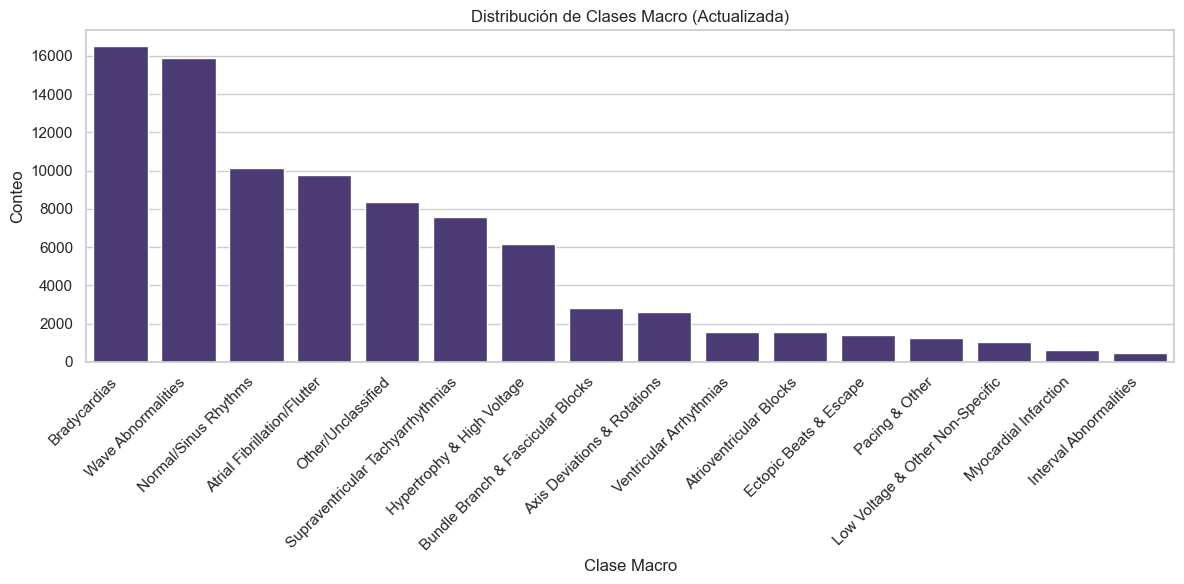

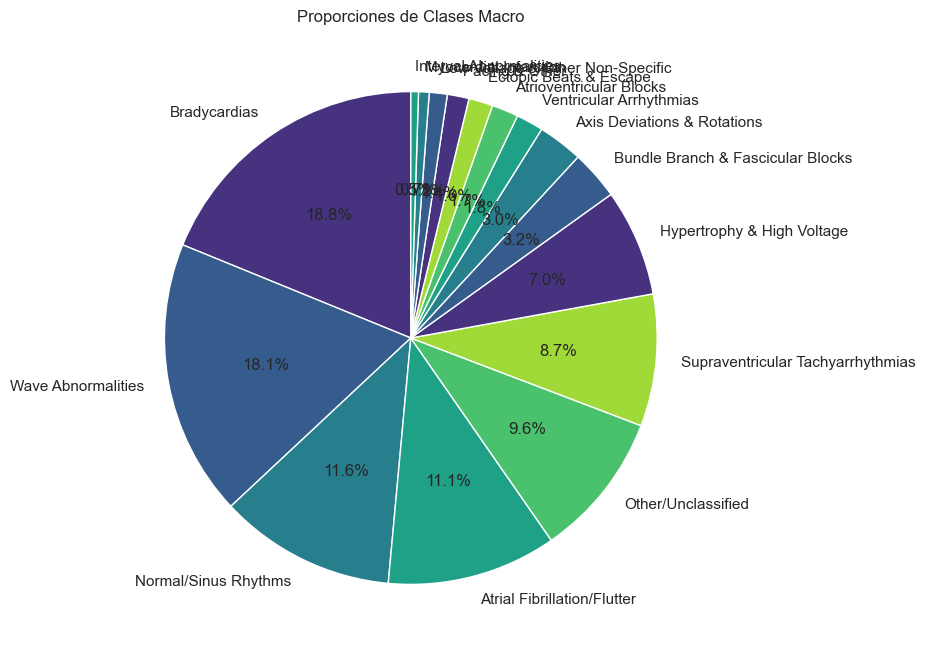

In [32]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Recomputa frecuencias de micro y macro (después de explode y merge)
micro_counts = df_merged['Full Name'].value_counts().head(20)
macro_counts = df_merged['macro_class'].value_counts()

# Imprime las tablas
print("Top 20 Micro Clases (Full Name):")
print(micro_counts)
print("\nFrecuencias de Macro Clases:")
print(macro_counts)

# Gráfico de barras para macro clases
plt.figure(figsize=(12, 6))
sns.barplot(x=macro_counts.index, y=macro_counts.values)
plt.xticks(rotation=45, ha='right')
plt.title('Distribución de Clases Macro (Actualizada)')
plt.ylabel('Conteo')
plt.xlabel('Clase Macro')
plt.tight_layout()
plt.show()

# Gráfico de pastel para proporciones
plt.figure(figsize=(8, 8))
plt.pie(macro_counts.values, labels=macro_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Proporciones de Clases Macro')
plt.show()

Distribución de Número de Etiquetas por ECG:
num_labels
1     20996
2     23666
3     18022
4     11859
5      7298
6      3630
7      1405
8       555
9       155
10       79
11       11
12       12
Name: count, dtype: int64

Top 10 Co-Ocurrencias de Micro Clases:
Full Name
Sinus Bradycardia                                    16505
Atrial Flutter                                        7973
Sinus Rhythm                                          7918
T wave Change                                         6962
Sinus Tachycardia                                     6565
Left ventricular hypertrophy (disorder)               5384
Electrocardiographic ST segment changes (finding)     4159
T wave opposite                                       2840
Sinus Irregularity                                    2226
Atrial Fibrillation                                   1780
dtype: int64


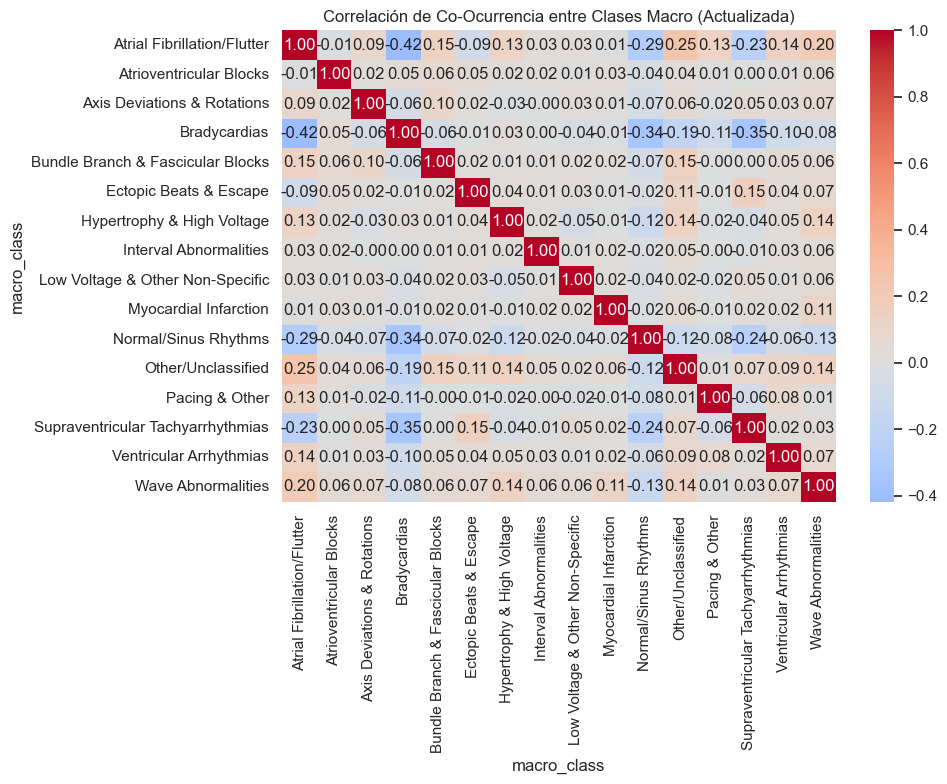

In [33]:
# Estadísticas por ECG (regresa al DF original sin explode)
df_merged['num_labels_avg'] = df_merged['num_labels']  # Ya lo tienes, pero verifica distribución
print("Distribución de Número de Etiquetas por ECG:")
print(df_merged['num_labels'].value_counts().sort_index())

# Top pares de co-ocurrencias (usa crosstab en exploded, agrupado por hea_path)
co_occ_pairs = pd.crosstab(df_merged['hea_path'], df_merged['Full Name']).sum().sort_values(ascending=False).head(10)
print("\nTop 10 Co-Ocurrencias de Micro Clases:")
print(co_occ_pairs)

# Matriz de correlación actualizada (solo para macro)
macro_pivot = pd.crosstab(df_merged['hea_path'], df_merged['macro_class'])
corr_matrix = macro_pivot.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlación de Co-Ocurrencia entre Clases Macro (Actualizada)')
plt.tight_layout()
plt.show()

In [34]:
# --- 5. PREPARACIÓN: grupos de edad y tablas macro/micro a nivel ECG ---
import numpy as np

# Limpieza básica
df['sex'] = df['sex'].str.upper().str.strip()
df['sex'] = df['sex'].replace({'MALE':'M','FEMALE':'F'})

# Definir grupos de edad (puedes ajustar cortes si lo prefieres)
edad_bins = [-1, 17, 29, 39, 49, 59, 69, 79, 89, np.inf]
edad_labels = ['0-17','18-29','30-39','40-49','50-59','60-69','70-79','80-89','90+']
df['age_group'] = pd.cut(df['age'], bins=edad_bins, labels=edad_labels)

# Asegurar datos explotados y mergeados disponibles (de celdas previas)
if 'df_merged' not in globals():
    df_ecg_exploded = df.copy()
    df_ecg_exploded['labels'] = df_ecg_exploded['labels'].str.split(',')
    df_ecg_exploded = df_ecg_exploded.explode('labels')
    df_ecg_exploded['labels'] = df_ecg_exploded['labels'].str.strip().astype(str)
    df_symbologia['Snomed_CT'] = df_symbologia['Snomed_CT'].astype(str)
    df_merged = pd.merge(df_ecg_exploded, df_symbologia, left_on='labels', right_on='Snomed_CT', how='left')
    # get_macro ya definido en celda anterior
    df_merged['macro_class'] = df_merged['Acronym Name'].apply(get_macro)

# Pivotes de presencia por ECG
macro_presence = pd.crosstab(df_merged['hea_path'], df_merged['macro_class']).clip(upper=1)
micro_presence = pd.crosstab(df_merged['hea_path'], df_merged['Full Name']).clip(upper=1)

# Añadir demografía a nivel ECG
demo = df[['hea_path','sex','age','age_group']].drop_duplicates('hea_path')
macro_demo = macro_presence.merge(demo, left_index=True, right_on='hea_path', how='left')
micro_demo = micro_presence.merge(demo, left_index=True, right_on='hea_path', how='left')

macro_demo.head(), micro_demo.shape


(   Atrial Fibrillation/Flutter  Atrioventricular Blocks  \
 0                            1                        0   
 1                            0                        0   
 2                            0                        0   
 3                            1                        0   
 4                            0                        0   
 
    Axis Deviations & Rotations  Bradycardias  \
 0                            0             0   
 1                            0             1   
 2                            0             1   
 3                            0             0   
 4                            0             1   
 
    Bundle Branch & Fascicular Blocks  Ectopic Beats & Escape  \
 0                                  1                       0   
 1                                  0                       0   
 2                                  0                       0   
 3                                  0                       0   
 4               

In [35]:
# --- 6. MACRO: asociaciones con sexo y edad ---
from scipy.stats import chi2_contingency, spearmanr

# 6.1 Prevalencia por sexo para cada macro
macro_cols = [c for c in macro_presence.columns if c not in ['hea_path','sex','age','age_group']]
prev_sex = []
for col in macro_cols:
    sub = macro_demo[[col,'sex']].dropna()
    tab = pd.crosstab(sub['sex'], sub[col])
    if tab.shape == (2,2):
        chi2, p, dof, exp = chi2_contingency(tab)
        # Riesgo/odds ratio simple (M vs F)
        # Añadimos continuidad 0.5 para evitar divisiones por cero
        a = tab.loc['M',1] if 1 in tab.columns and 'M' in tab.index else 0
        b = tab.loc['M',0] if 0 in tab.columns and 'M' in tab.index else 0
        c = tab.loc['F',1] if 1 in tab.columns and 'F' in tab.index else 0
        d = tab.loc['F',0] if 0 in tab.columns and 'F' in tab.index else 0
        or_val = ((a+0.5)/(b+0.5))/((c+0.5)/(d+0.5)) if (b+0.5)*(d+0.5) > 0 else np.nan
        prev_M = a/(a+b) if (a+b)>0 else np.nan
        prev_F = c/(c+d) if (c+d)>0 else np.nan
        prev_sex.append({'macro': col, 'prev_M': prev_M, 'prev_F': prev_F, 'diff_M_minus_F': (prev_M - prev_F) if pd.notnull(prev_M) and pd.notnull(prev_F) else np.nan, 'chi2_p': p, 'odds_ratio_M_vs_F': or_val})

prev_sex_df = pd.DataFrame(prev_sex).sort_values('diff_M_minus_F', ascending=False)
prev_sex_df.head(15)


,macro,prev_M,prev_F,diff_M_minus_F,chi2_p,odds_ratio_M_vs_F
3,Bradycardias,0.423920,0.319265,0.104655,1.497696e-110,1.568967
6,Hypertrophy & High Voltage,0.176884,0.093459,0.083425,2.813358e-136,2.084121
4,Bundle Branch & Fascicular Blocks,0.073279,0.038994,0.034285,1.049747e-51,1.947997
0,Atrial Fibrillation/Flutter,0.233396,0.210440,0.022955,1.223583e-08,1.142256
2,Axis Deviations & Rotations,0.067839,0.045677,0.022162,1.313855e-22,1.520078
1,Atrioventricular Blocks,0.043115,0.024312,0.018803,3.646936e-26,1.807146
14,Ventricular Arrhythmias,0.041856,0.026785,0.015071,3.361329e-17,1.586456
12,Pacing & Other,0.032194,0.023786,0.008408,1.974187e-07,1.364615
5,Ectopic Beats & Escape,0.033818,0.027785,0.006033,3.616167e-04,1.224303
15,Wave Abnormalities,0.254019,0.249171,0.004848,2.519858e-01,1.026063


In [36]:
# 6.2 Asociación con edad: correlación Spearman por macro
# Estrategia: usar edad continua y presencia binaria por macro
age_macro_corr = []
for col in macro_cols:
    sub = macro_demo[[col,'age']].dropna()
    if sub['age'].nunique() > 1:
        rho, p = spearmanr(sub['age'], sub[col])
        age_macro_corr.append({'macro': col, 'spearman_rho': rho, 'p_value': p})

age_macro_corr_df = pd.DataFrame(age_macro_corr).sort_values('spearman_rho', ascending=False)
age_macro_corr_df.head(15)


,macro,spearman_rho,p_value
0,Atrial Fibrillation/Flutter,0.421786,0.000000e+00
15,Wave Abnormalities,0.240868,0.000000e+00
11,Other/Unclassified,0.204982,0.000000e+00
6,Hypertrophy & High Voltage,0.167935,3.245528e-273
4,Bundle Branch & Fascicular Blocks,0.166239,1.090365e-267
5,Ectopic Beats & Escape,0.132746,1.369990e-170
12,Pacing & Other,0.130494,7.169943e-165
1,Atrioventricular Blocks,0.116577,9.241708e-132
14,Ventricular Arrhythmias,0.109978,2.135270e-117
2,Axis Deviations & Rotations,0.078825,4.719998e-61


In [37]:
# --- 7. MICRO (top 30): asociaciones con sexo y edad ---
# Seleccionar top 30 micro por prevalencia
micro_freq = micro_presence.sum().sort_values(ascending=False)
top_micro = list(micro_freq.head(30).index)

micro_top_demo = micro_demo[top_micro + ['sex','age','age_group','hea_path']].copy()

# 7.1 Sexo
from scipy.stats import chi2_contingency
rows = []
for col in top_micro:
    sub = micro_top_demo[[col,'sex']].dropna()
    tab = pd.crosstab(sub['sex'], sub[col])
    if tab.shape == (2,2):
        chi2, p, *_ = chi2_contingency(tab)
        a = tab.loc['M',1] if 1 in tab.columns and 'M' in tab.index else 0
        b = tab.loc['M',0] if 0 in tab.columns and 'M' in tab.index else 0
        c = tab.loc['F',1] if 1 in tab.columns and 'F' in tab.index else 0
        d = tab.loc['F',0] if 0 in tab.columns and 'F' in tab.index else 0
        or_val = ((a+0.5)/(b+0.5))/((c+0.5)/(d+0.5)) if (b+0.5)*(d+0.5) > 0 else np.nan
        prev_M = a/(a+b) if (a+b)>0 else np.nan
        prev_F = c/(c+d) if (c+d)>0 else np.nan
        rows.append({'micro': col, 'prev_M': prev_M, 'prev_F': prev_F, 'diff_M_minus_F': (prev_M - prev_F) if pd.notnull(prev_M) and pd.notnull(prev_F) else np.nan, 'chi2_p': p, 'odds_ratio_M_vs_F': or_val})

micro_sex_df = pd.DataFrame(rows).sort_values('diff_M_minus_F', ascending=False)

# 7.2 Edad (Spearman)
rows = []
for col in top_micro:
    sub = micro_top_demo[[col,'age']].dropna()
    if sub['age'].nunique() > 1:
        rho, p = spearmanr(sub['age'], sub[col])
        rows.append({'micro': col, 'spearman_rho': rho, 'p_value': p})

micro_age_df = pd.DataFrame(rows).sort_values('spearman_rho', ascending=False)

micro_sex_df.head(15), micro_age_df.head(15)


(                                                micro    prev_M    prev_F  \
 0                                   Sinus Bradycardia  0.423798  0.319160   
 5             Left ventricular hypertrophy (disorder)  0.159264  0.076883   
 11                                    Axis left shift  0.046444  0.020207   
 1                                      Atrial Flutter  0.191133  0.171552   
 21                                       ST extension  0.026388  0.007315   
 18                                    abnormal Q wave  0.031991  0.014261   
 15                    1 degree atrioventricular block  0.032965  0.016576   
 16  Electrocardiographic complete right bundle bra...  0.030570  0.017524   
 17  Electrocardiogram: premature ventricular contr...  0.029920  0.017208   
 13            Rhythm from artificial pacing (finding)  0.030489  0.022365   
 25                          right bundle branch block  0.018188  0.010525   
 28      Finding of electrocardiogram R wave (finding)  0.017701

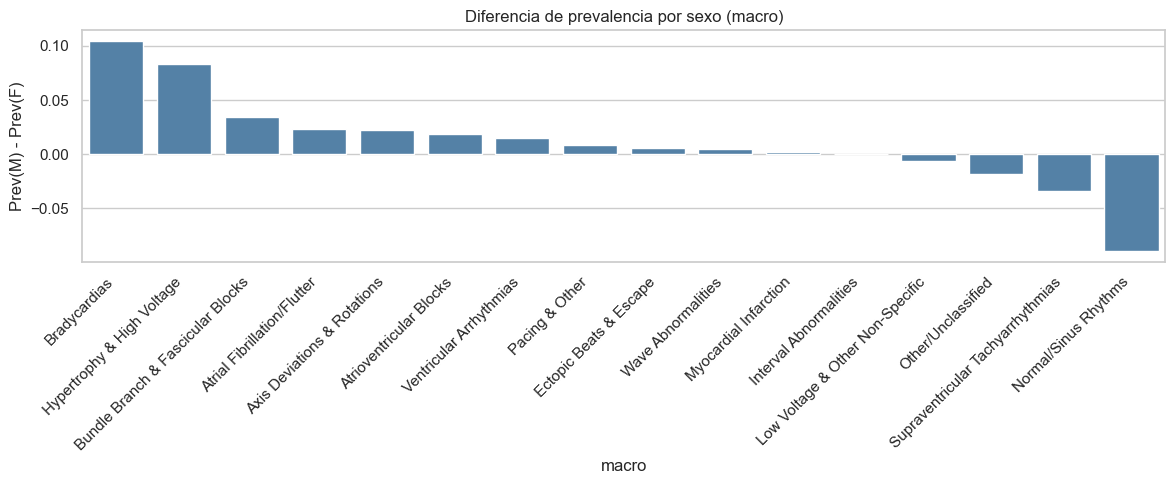

In [38]:
# --- 8. Visualizaciones clave ---
import seaborn as sns
import matplotlib.pyplot as plt

# 8.1 Barras diferencias por sexo (macro)
plt.figure(figsize=(12,5))
sns.barplot(data=prev_sex_df.sort_values('diff_M_minus_F', ascending=False), x='macro', y='diff_M_minus_F', color='steelblue')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Prev(M) - Prev(F)')
plt.title('Diferencia de prevalencia por sexo (macro)')
plt.tight_layout()
plt.show()


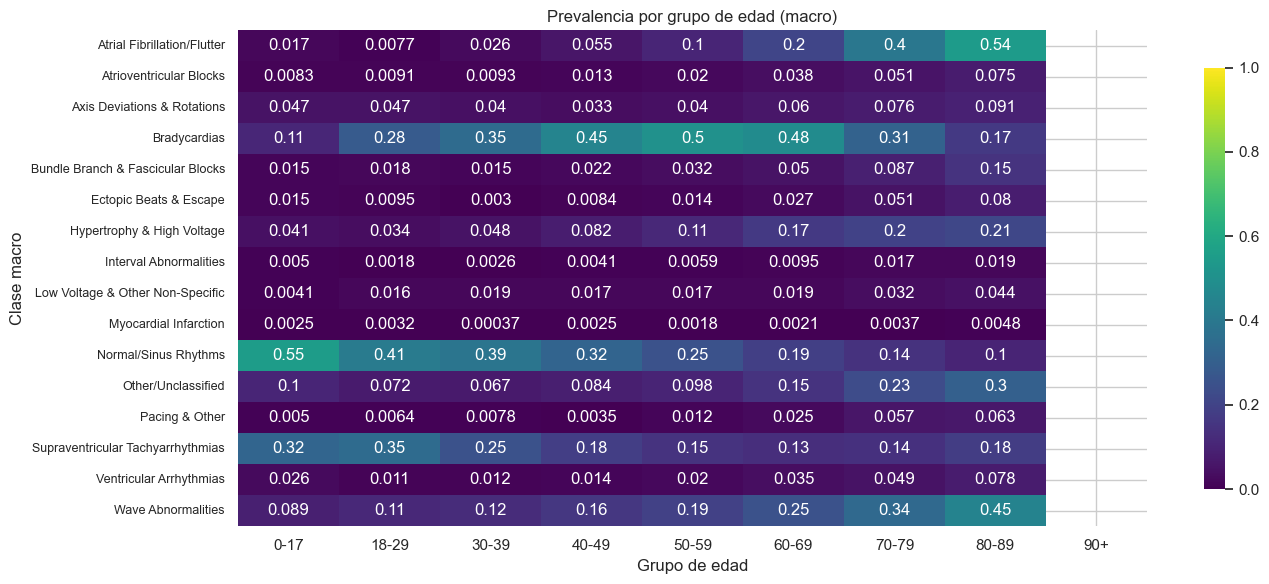

In [39]:
# 8.2b Heatmap macro por grupos de edad (mejorado)
# Reordenamos age_group y transponemos para que los grupos estén en X
orden_edades = ['0-17','18-29','30-39','40-49','50-59','60-69','70-79','80-89','90+']
macro_by_age = macro_demo.groupby('age_group', observed=True)[macro_cols].mean()
macro_by_age = macro_by_age.reindex(orden_edades)
plt.figure(figsize=(14,6))
ax = sns.heatmap(macro_by_age.T, annot=True, cmap='viridis', vmin=0, vmax=1, cbar_kws={'shrink':0.85})
ax.set_xlabel('Grupo de edad')
ax.set_ylabel('Clase macro')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha='center')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.title('Prevalencia por grupo de edad (macro)')
plt.tight_layout()
plt.show()


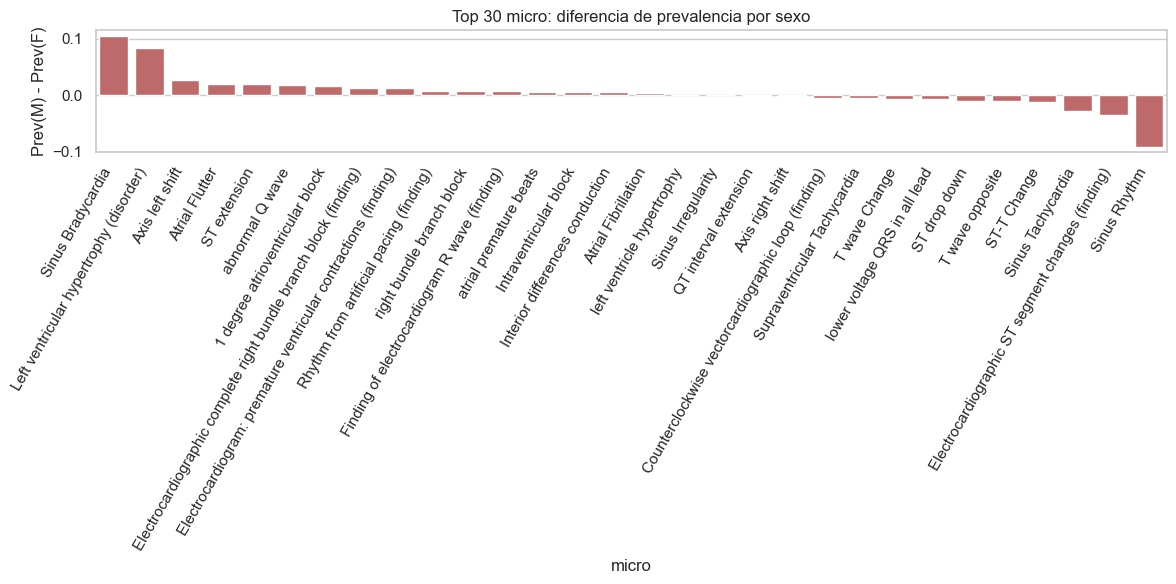

In [40]:

# 8.3 Barras diferencias por sexo (micro top 30)
plt.figure(figsize=(12,6))
sns.barplot(data=micro_sex_df, x='micro', y='diff_M_minus_F', color='indianred')
plt.xticks(rotation=60, ha='right')
plt.ylabel('Prev(M) - Prev(F)')
plt.title('Top 30 micro: diferencia de prevalencia por sexo')
plt.tight_layout()
plt.show()



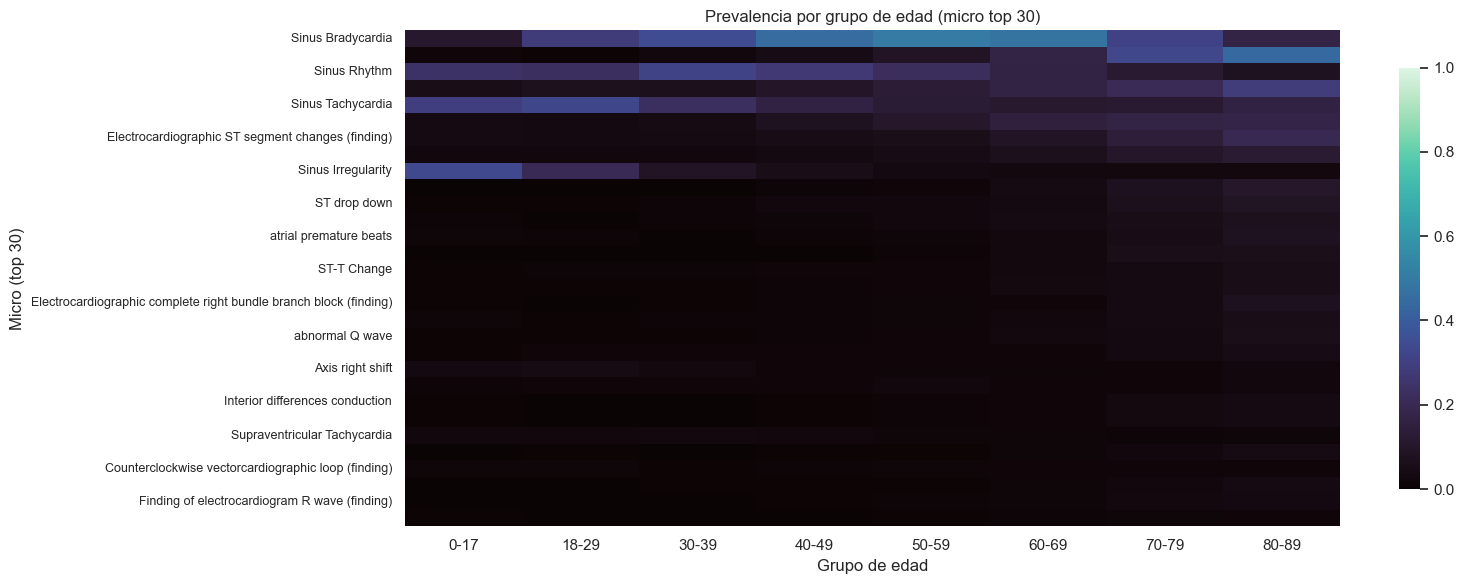

In [41]:
# 8.4b Heatmap micro top 30 por grupos de edad (mejorado)
# Transponemos para que los grupos de edad estén en el eje X y no se superpongan
micro_by_age = micro_top_demo.groupby('age_group', observed=True)[top_micro].mean()
plt.figure(figsize=(16,6))
ax = sns.heatmap(micro_by_age.T, cmap='mako', vmin=0, vmax=1, cbar_kws={'shrink':0.85})
ax.set_xlabel('Grupo de edad')
ax.set_ylabel('Micro (top 30)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha='center')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.title('Prevalencia por grupo de edad (micro top 30)')
plt.tight_layout()
plt.show()


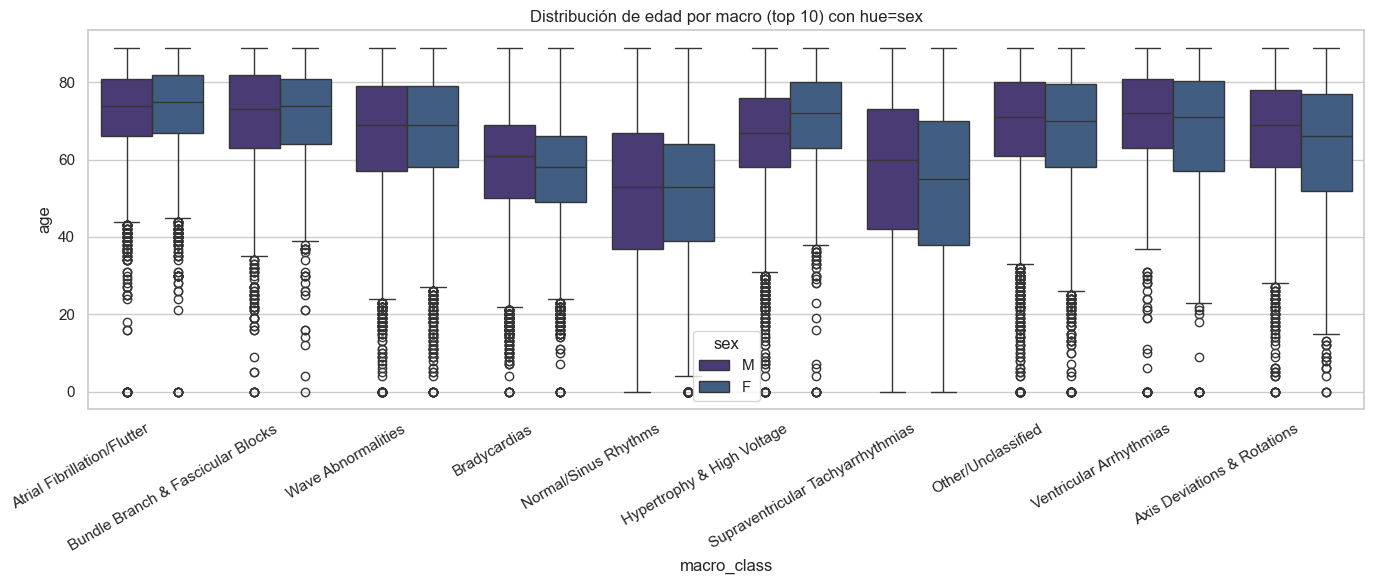

C:\Users\pevv2\AppData\Local\Temp\ipykernel_24200\1621112987.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prev_table = inter_df.groupby(['age_group','sex'])[top_macros].mean().unstack('sex')


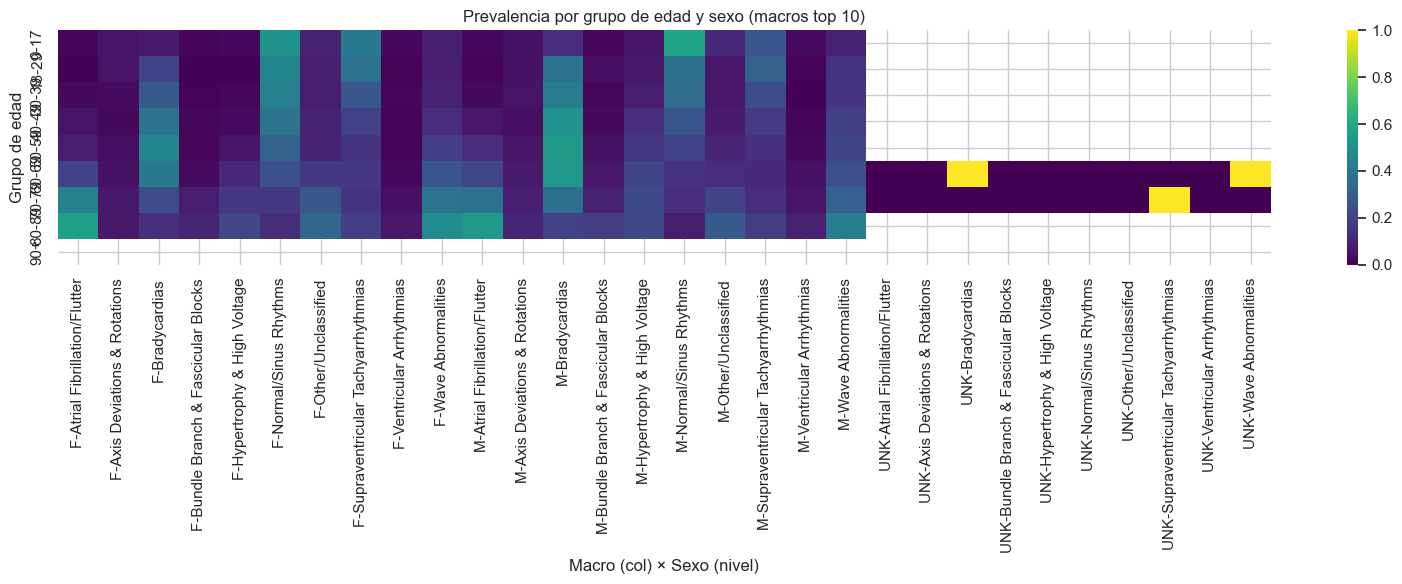

In [42]:
# --- 9. Interacción sexo-edad ---
import seaborn as sns
import matplotlib.pyplot as plt

# 9.1 Boxplots de edad por macro con hue=sex (top 10 macros por prevalencia)
macro_freq = macro_presence.sum().sort_values(ascending=False)
top_macros = list(macro_freq.head(10).index)

plot_df = df_merged.drop_duplicates(['hea_path','macro_class'])
plot_df = plot_df[plot_df['macro_class'].isin(top_macros)]
plt.figure(figsize=(14,6))
sns.boxplot(data=plot_df, x='macro_class', y='age', hue='sex')
plt.xticks(rotation=30, ha='right')
plt.title('Distribución de edad por macro (top 10) con hue=sex')
plt.tight_layout()
plt.show()

# 9.2 Heatmap de prevalencia por (age_group, sex) para macros top 10
inter_df = macro_demo.copy()
inter_df['sex'] = inter_df['sex'].fillna('UNK')
prev_table = inter_df.groupby(['age_group','sex'])[top_macros].mean().unstack('sex')
plt.figure(figsize=(16,6))
ax = sns.heatmap(prev_table.swaplevel(axis=1).sort_index(axis=1), cmap='viridis', vmin=0, vmax=1)
ax.set_xlabel('Macro (col) × Sexo (nivel)')
ax.set_ylabel('Grupo de edad')
plt.title('Prevalencia por grupo de edad y sexo (macros top 10)')
plt.tight_layout()
plt.show()


In [43]:
# --- 10b. VIF robusto (limpieza de tipos y no finitos) ---
import numpy as np
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Construcción de matriz de diseño numérica
X = macro_demo[['age','sex']].copy()
X['age'] = pd.to_numeric(X['age'], errors='coerce')
X['age_gt_65'] = (X['age'] > 65).astype(float)
X['sex'] = X['sex'].astype(str).str.upper().map({'M':'M','F':'F'})
X = pd.get_dummies(X, columns=['sex'], drop_first=True, dtype=float)

# Quitar filas con NaN y columnas constantes (varianza cero)
X = X.dropna(axis=0)
const_cols = [c for c in X.columns if X[c].nunique(dropna=True) <= 1]
X = X.drop(columns=const_cols, errors='ignore')

# Añadir constante y asegurar float
if X.shape[1] == 0:
    print('No hay predictores válidos para VIF tras limpieza.')
else:
    X_ = X.assign(const=1.0)
    X_ = X_.apply(pd.to_numeric, errors='coerce').astype(float)
    # Filtra filas con valores no finitos
    mask = np.isfinite(X_.to_numpy()).all(axis=1)
    X_ = X_.loc[mask]

    if X_.shape[1] < 2:
        print('Columnas insuficientes para VIF (se requiere >= 2 incluyendo la constante).')
    else:
        arr = X_.to_numpy(dtype=float)
        features = list(X_.columns)
        vif_vals = [variance_inflation_factor(arr, i) for i in range(arr.shape[1])]
        vif_df = pd.DataFrame({'feature': features, 'VIF': vif_vals})
        vif_df = vif_df[vif_df['feature'] != 'const'].sort_values('VIF', ascending=False)
        display(vif_df)
        # Señalamos posibles multicolinealidades fuertes
        high_vif = vif_df[vif_df['VIF'] >= 5]
        if not high_vif.empty:
            print('\nPosibles problemas de multicolinealidad (VIF>=5):')
            display(high_vif)


,feature,VIF
1,age_gt_65,2.334282
0,age,2.330536
2,sex_M,1.005531


In [44]:
# --- 11. Pipeline ML: estratificación por edad/sexo, SMOTE por subgrupos, RF multilabel ---
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
from sklearn.preprocessing import MultiLabelBinarizer
from imblearn.over_sampling import SMOTE

# Etiquetas macro multilabel por ECG
Y_macro = macro_presence.copy()
Y_macro = Y_macro.reindex(sorted(Y_macro.columns), axis=1)

# Features demográficas
F = df[['hea_path','age','sex']].drop_duplicates('hea_path')
F['age_gt_65'] = (F['age']>65).astype(int)
F = pd.get_dummies(F, columns=['sex'], drop_first=True)

# Unir con Y y dropna
XY = Y_macro.merge(F, left_index=True, right_on='hea_path', how='left').dropna()
Y = XY[Y_macro.columns]
X = XY[['age','age_gt_65'] + [c for c in XY.columns if c.startswith('sex_')]]

# Estratificación por bins de edad y sexo
strata = pd.cut(XY['age'], bins=[-1,29,49,65,120], labels=['<=29','30-49','50-65','>65']).astype(str) + '_' + \
         XY[[c for c in XY.columns if c.startswith('sex_')]].idxmax(axis=1).str.replace('sex_','')

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=strata)

# SMOTE por subgrupos (aplicamos SMOTE en cada subgrupo y concatenamos)
X_res_list, Y_res_list = [], []
train_df = X_train.join(Y_train)
train_df['stratum'] = pd.cut(train_df['age'], bins=[-1,29,49,65,120], labels=['<=29','30-49','50-65','>65']).astype(str) + '_' + \
                      X_train[[c for c in X_train.columns if c.startswith('sex_')]].idxmax(axis=1).str.replace('sex_','')

for grp, part in train_df.groupby('stratum'):
    if part.shape[0] < 10:
        continue
    X_sub = part[X.columns]
    Y_sub = part[Y.columns]
    # SMOTE solo para una pseudo-etiqueta agregada (suma de macros>0) para balancear presencia vs ausencia
    y_binary = (Y_sub.sum(axis=1) > 0).astype(int)
    try:
        X_bal, y_bal = SMOTE(random_state=42, k_neighbors=min(5, y_binary.sum()-1) if y_binary.sum()>1 else 1).fit_resample(X_sub, y_binary)
        # Mantener Y_sub original para esos índices re-muestreados no es directo; simplificación: replicamos filas minoritarias
        if y_binary.sum() > 0 and y_binary.sum() < len(y_binary):
            idx_min = y_binary[y_binary==1].index
            reps = len(y_bal) - len(y_binary)
            if reps > 0:
                extra_idx = np.random.choice(idx_min, size=reps, replace=True)
                X_sub_aug = pd.concat([X_sub, X_sub.loc[extra_idx]])
                Y_sub_aug = pd.concat([Y_sub, Y_sub.loc[extra_idx]])
            else:
                X_sub_aug, Y_sub_aug = X_sub, Y_sub
        else:
            X_sub_aug, Y_sub_aug = X_sub, Y_sub
        X_res_list.append(X_sub_aug)
        Y_res_list.append(Y_sub_aug)
    except Exception:
        X_res_list.append(X_sub)
        Y_res_list.append(Y_sub)

X_res = pd.concat(X_res_list)
Y_res = pd.concat(Y_res_list)

# Entrenar RF one-vs-rest (multietiqueta=columnas independientes)
rf = RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced_subsample', n_jobs=-1)
rf.fit(X_res, Y_res)

Y_pred = pd.DataFrame(rf.predict(X_test), columns=Y.columns, index=Y_test.index)

# F1 por macro, ponderado por prevalencia
prevalencia = Y_test.mean()
f1_por_macro = {}
for col in Y.columns:
    f1 = f1_score(Y_test[col], Y_pred[col]) if Y_test[col].nunique()>1 else np.nan
    f1_por_macro[col] = f1

f1_df = pd.Series(f1_por_macro).to_frame('F1')
f1_df['prevalencia'] = prevalencia
f1_ponderado = (f1_df['F1'] * f1_df['prevalencia']).sum() / f1_df['prevalencia'].sum()

f1_df.sort_values('F1', ascending=False).head(15), f1_ponderado


(                                         F1  prevalencia
 Wave Abnormalities                 0.406360     0.251691
 Atrial Fibrillation/Flutter        0.281070     0.223942
 Other/Unclassified                 0.273614     0.154340
 Supraventricular Tachyarrhythmias  0.266320     0.173719
 Bradycardias                       0.230917     0.380461
 Hypertrophy & High Voltage         0.212994     0.146543
 Normal/Sinus Rhythms               0.174943     0.224286
 Bundle Branch & Fascicular Blocks  0.112396     0.054810
 Axis Deviations & Rotations        0.106141     0.058136
 Ventricular Arrhythmias            0.086833     0.035202
 Atrioventricular Blocks            0.081372     0.036120
 Ectopic Beats & Escape             0.070246     0.029240
 Pacing & Other                     0.058968     0.024309
 Low Voltage & Other Non-Specific   0.048396     0.024882
 Interval Abnormalities             0.018499     0.009976,
 np.float64(0.23781343918303186))

C:\Users\pevv2\AppData\Local\Temp\ipykernel_24200\1267711293.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp = inter_df[inter_df['sex']==s].groupby('age_group')[macros_show].mean().reindex(orden_edades)
C:\Users\pevv2\AppData\Local\Temp\ipykernel_24200\1267711293.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp = inter_df[inter_df['sex']==s].groupby('age_group')[macros_show].mean().reindex(orden_edades)


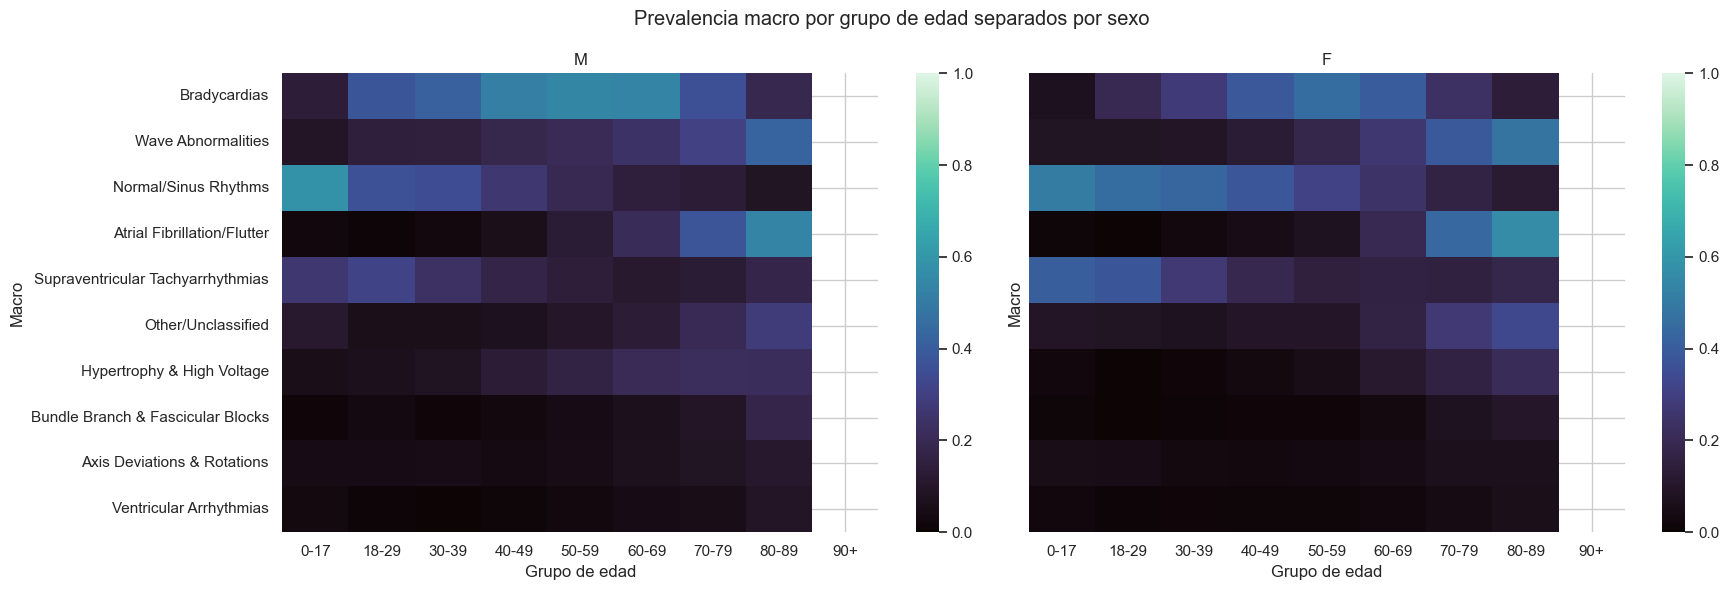

In [45]:
# --- 12. Co-ocurrencias con demografía (macro x sex x age_group) ---
# Tabla 3D resumida como panel de heatmaps por sexo
inter_df = macro_demo.copy()
orden_edades = ['0-17','18-29','30-39','40-49','50-59','60-69','70-79','80-89','90+']
macros_show = top_macros

fig, axes = plt.subplots(1, 2, figsize=(18,6), sharey=True)
for ax, s in zip(axes, ['M','F']):
    tmp = inter_df[inter_df['sex']==s].groupby('age_group')[macros_show].mean().reindex(orden_edades)
    sns.heatmap(tmp.T, ax=ax, cmap='mako', vmin=0, vmax=1)
    ax.set_title(f'{s}')
    ax.set_xlabel('Grupo de edad')
    ax.set_ylabel('Macro')
plt.suptitle('Prevalencia macro por grupo de edad separados por sexo')
plt.tight_layout()
plt.show()


In [46]:
# --- 14. Reporte: pandas profiling sobre DF enriquecido ---
# Instalar si es necesario: pip install ydata-profiling
from ydata_profiling import ProfileReport

enriched = macro_demo.merge(micro_presence, left_on='hea_path', right_index=True, how='left')
profile = ProfileReport(enriched.sample(min(5000, len(enriched)), random_state=42), title='ECG Enriched Profile', minimal=True)
profile.to_file('ecg_enriched_profile.html')
'Generado: ecg_enriched_profile.html'


c:\Users\pevv2\OneDrive\Documentos\TESIS\2_Modleo_AtencionPrimero\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Export report to file: 100%|██████████| 1/1 [00:00<00:00, 30.30it/s]


'Generado: ecg_enriched_profile.html'

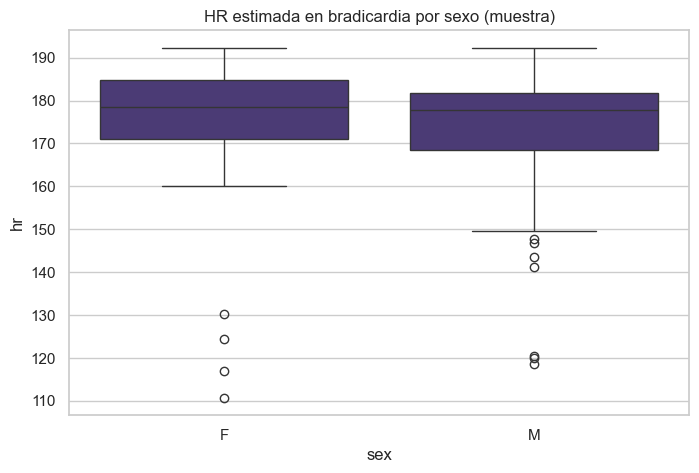

(count    200.000000
 mean     174.041127
 std       14.266801
 min      110.701107
 25%      169.014085
 50%      178.041543
 75%      182.926829
 max      192.307692
 Name: hr, dtype: float64,
 sex
 F    178.571429
 M    177.778168
 Name: hr, dtype: float64)

In [47]:
# --- 13. Carga de señales (.mat) y comparación de HR por subgrupo ---
import os
import scipy.io as sio
import numpy as np
import pandas as pd

# Función simple para estimar HR desde lead II por picos (muy básica, placeholder)
from scipy.signal import find_peaks

def estimate_hr(signal, fs=500.0):
    if signal is None or len(signal)==0:
        return np.nan
    # Normaliza y detecta picos
    x = (signal - np.mean(signal)) / (np.std(signal)+1e-6)
    peaks, _ = find_peaks(x, distance=int(fs*0.3))  # >300ms
    if len(peaks) < 2:
        return np.nan
    rr = np.diff(peaks) / fs
    rr = rr[(rr>0.3) & (rr<2.0)]  # filtra artefactos (30-200 bpm)
    if len(rr)==0:
        return np.nan
    hr = 60.0 / np.median(rr)
    return hr

root = r'C:\Users\pevv2\OneDrive\Documentos\TESIS\2_Modleo_AtencionPrimero\datos\12Large\WFDBRecords'

# Selecciona bradicardia y subgrupos M/F
brady_mask = macro_demo['Bradycardias']==1
sub_df = macro_demo.loc[brady_mask, ['hea_path','sex','age']].copy()

hrs = []
for rel in sub_df['hea_path'].head(200):  # limitar por rapidez
    mat_path = os.path.join(root, rel).replace('.hea','.mat')
    if not os.path.exists(mat_path):
        continue
    try:
        m = sio.loadmat(mat_path)
        sig = m.get('val')  # formato PhysioNet: (n_leads, n_samples)
        if sig is None:
            continue
        lead_ii = sig[1, :] if sig.shape[0] > 1 else sig[0, :]
        hr = estimate_hr(lead_ii.astype(float), fs=500.0)
        hrs.append({'hea_path': rel, 'hr': hr})
    except Exception:
        continue

hrs_df = pd.DataFrame(hrs)
sub_df = sub_df.merge(hrs_df, on='hea_path', how='left')

# Comparación simple M vs F
plt.figure(figsize=(8,5))
sns.boxplot(data=sub_df, x='sex', y='hr')
plt.title('HR estimada en bradicardia por sexo (muestra)')
plt.show()

sub_df['hr'].describe(), sub_df.groupby('sex')['hr'].median()


In [48]:
# --- A. Validación cobertura age/sex e imputación por macro ---
import numpy as np
import pandas as pd

print("[VALIDACIÓN] Cobertura age/sex")
cover_age = df['age'].notna().mean()
cover_sex = df['sex'].notna().mean()
print(f"Cobertura age: {cover_age:.3%}")
print(f"Cobertura sex: {cover_sex:.3%}")

# Reglas: imputar 'sex' desconocido como 'UNK' para no perder filas en cruces
# Imputación de edad por mediana dentro de macro_class, si no, global
print("[IMPUTACIÓN] Edad por mediana de macro; fallback global")

# Garantiza df_merged existente con macro_class
if 'df_merged' not in globals():
    df_ecg_exploded = df.copy()
    df_ecg_exploded['labels'] = df_ecg_exploded['labels'].str.split(',')
    df_ecg_exploded = df_ecg_exploded.explode('labels')
    df_ecg_exploded['labels'] = df_ecg_exploded['labels'].str.strip().astype(str)
    df_symbologia['Snomed_CT'] = df_symbologia['Snomed_CT'].astype(str)
    df_merged = pd.merge(df_ecg_exploded, df_symbologia, left_on='labels', right_on='Snomed_CT', how='left')
    df_merged['macro_class'] = df_merged['Acronym Name'].apply(get_macro)

# Demografía base
demo = df[['hea_path','age','sex']].drop_duplicates('hea_path')
macro_by_ecg = df_merged[['hea_path','macro_class']].drop_duplicates()

demo_macro = demo.merge(macro_by_ecg, on='hea_path', how='left')

# Medianas por macro
median_age_by_macro = demo_macro.groupby('macro_class', observed=True)['age'].median()
global_median_age = demo_macro['age'].median()

# Imputación
imputed_age = []
for _, row in demo_macro.iterrows():
    if pd.notna(row['age']):
        imputed_age.append(row['age'])
    else:
        med = median_age_by_macro.get(row['macro_class'], np.nan)
        if pd.isna(med):
            med = global_median_age
        imputed_age.append(med)

demo_macro['age_imputed'] = imputed_age

# sex: fillna a 'UNK'
demo_macro['sex_imputed'] = demo_macro['sex'].fillna('UNK').str.upper()

# Métrica de cobertura alcanzada
cov_age_after = demo_macro['age_imputed'].notna().mean()
print(f"Cobertura age tras imputación: {cov_age_after:.3%}")

# Exporta un DF de features demográficas limpias a nivel ECG
features_demo = demo_macro[['hea_path','age_imputed','sex_imputed']].drop_duplicates('hea_path')
features_demo.rename(columns={'age_imputed':'age','sex_imputed':'sex'}, inplace=True)
features_demo.head()


[VALIDACIÓN] Cobertura age/sex
Cobertura age: 99.874%
Cobertura sex: 99.950%
[IMPUTACIÓN] Edad por mediana de macro; fallback global
Cobertura age tras imputación: 100.000%


,hea_path,age,sex
0,01/010/JS00001.hea,85.0,M
3,01/010/JS00002.hea,59.0,F
5,01/010/JS00004.hea,66.0,M
6,01/010/JS00005.hea,73.0,F
8,01/010/JS00006.hea,46.0,F


In [49]:
# --- B. Extracción HR desde .mat y fusión con features ---
import os
import numpy as np
import pandas as pd
import scipy.io as sio
from scipy.signal import find_peaks

# Reutiliza estimate_hr si existe; si no, define
if 'estimate_hr' not in globals():
    def estimate_hr(signal, fs=500.0):
        if signal is None or len(signal)==0:
            return np.nan
        x = (signal - np.mean(signal)) / (np.std(signal)+1e-6)
        peaks, _ = find_peaks(x, distance=int(fs*0.3))
        if len(peaks) < 2:
            return np.nan
        rr = np.diff(peaks) / fs
        rr = rr[(rr>0.3) & (rr<2.0)]
        if len(rr)==0:
            return np.nan
        return 60.0 / np.median(rr)

root = r'C:\Users\pevv2\OneDrive\Documentos\TESIS\2_Modleo_AtencionPrimero\datos\12Large\WFDBRecords'

# Lista base de ECG a procesar
base_list = features_demo['hea_path'].tolist()

hr_rows = []
for rel in base_list:
    mat_path = os.path.join(root, rel).replace('.hea','.mat')
    if not os.path.exists(mat_path):
        hr_rows.append({'hea_path': rel, 'hr': np.nan})
        continue
    try:
        m = sio.loadmat(mat_path)
        sig = m.get('val')
        if sig is None:
            hr_rows.append({'hea_path': rel, 'hr': np.nan})
            continue
        lead_ii = sig[1, :] if sig.shape[0] > 1 else sig[0, :]
        hr = estimate_hr(lead_ii.astype(float), fs=500.0)
        hr_rows.append({'hea_path': rel, 'hr': hr})
    except Exception:
        hr_rows.append({'hea_path': rel, 'hr': np.nan})

hr_df = pd.DataFrame(hr_rows)

# Imputa HR por mediana por macro; si no disponible, global
macro_any = df_merged[['hea_path','macro_class']].drop_duplicates()
hr_enriched = features_demo.merge(hr_df, on='hea_path', how='left').merge(macro_any, on='hea_path', how='left')

median_hr_by_macro = hr_enriched.groupby('macro_class', observed=True)['hr'].median()
global_median_hr = hr_enriched['hr'].median()
hr_enriched['hr_imputed'] = hr_enriched.apply(
    lambda r: r['hr'] if pd.notna(r['hr']) else (median_hr_by_macro.get(r['macro_class'], np.nan) if pd.notna(median_hr_by_macro.get(r['macro_class'], np.nan)) else global_median_hr),
    axis=1
)

print("HR cobertura bruta:", hr_df['hr'].notna().mean())
print("HR cobertura tras imputación:", hr_enriched['hr_imputed'].notna().mean())

hr_enriched.head()


HR cobertura bruta: 1.0
HR cobertura tras imputación: 1.0


,hea_path,age,sex,hr,macro_class,hr_imputed
0,01/010/JS00001.hea,85.0,M,113.207547,Atrial Fibrillation/Flutter,113.207547
1,01/010/JS00001.hea,85.0,M,113.207547,Bundle Branch & Fascicular Blocks,113.207547
2,01/010/JS00001.hea,85.0,M,113.207547,Wave Abnormalities,113.207547
3,01/010/JS00002.hea,59.0,F,164.383562,Bradycardias,164.383562
4,01/010/JS00002.hea,59.0,F,164.383562,Wave Abnormalities,164.383562


In [51]:
print(hr_enriched.groupby('macro_class')['hr_imputed'].agg(['mean', 'median', 'std']).round(2))
print("\nPor sexo:")
print(hr_enriched.groupby(['sex', 'macro_class'])['hr_imputed'].mean().unstack().round(2))

                                     mean  median    std
macro_class                                             
Atrial Fibrillation/Flutter        156.82  157.89  17.68
Atrioventricular Blocks            158.60  165.98  25.23
Axis Deviations & Rotations        152.87  157.89  25.32
Bradycardias                       173.38  176.47  13.22
Bundle Branch & Fascicular Blocks  156.24  160.86  23.67
Ectopic Beats & Escape             151.83  157.89  26.45
Hypertrophy & High Voltage         158.91  164.84  23.51
Interval Abnormalities             156.15  162.16  22.95
Low Voltage & Other Non-Specific   152.09  157.48  26.64
Myocardial Infarction              146.07  149.26  24.09
Normal/Sinus Rhythms               163.56  165.75  21.27
Other/Unclassified                 150.16  153.45  24.78
Pacing & Other                     160.17  163.04  20.62
Supraventricular Tachyarrhythmias  121.15  112.57  21.91
Ventricular Arrhythmias            152.97  155.44  21.61
Wave Abnormalities             

In [52]:
import os
import numpy as np
import pandas as pd
import scipy.io as sio
from scipy.signal import find_peaks, butter, filtfilt

def estimate_hr_improved(signal, fs=500.0):
    if signal is None or len(signal) < fs * 2:  # Min 2s
        return np.nan
    # 1. Bandpass 5-15 Hz (QRS)
    nyq = fs / 2
    low, high = 5 / nyq, 15 / nyq
    b, a = butter(4, [low, high], btype='band')
    filtered = filtfilt(b, a, signal)
    # 2. Derivada + squaring para slope QRS
    deriv = np.diff(filtered)
    sq = deriv ** 2
    # 3. Moving window integration (36 samples ~72ms)
    win = int(0.072 * fs)
    integ = np.convolve(sq, np.ones(win), mode='same')
    # 4. Peaks con prominence (evita ruido) y distance flexible (min 40 bpm ~1.5s)
    prom = np.std(integ) * 0.3  # Ajustable
    peaks, _ = find_peaks(integ, distance=int(fs * 0.4), prominence=prom)
    if len(peaks) < 2:
        return np.nan
    rr = np.diff(peaks) / fs
    # 5. Filtro RR amplio (0.4-3s para bradi/taqui extrema)
    rr = rr[(rr > 0.4) & (rr < 3.0)]
    if len(rr) < 2:
        return np.nan
    # 6. Mediana RR (robusta a outliers)
    return 60.0 / np.median(rr)

# Re-ejecuta el loop con la función nueva
hr_rows = []
for rel in base_list:
    mat_path = os.path.join(root, rel).replace('.hea','.mat')
    if not os.path.exists(mat_path):
        hr_rows.append({'hea_path': rel, 'hr': np.nan})
        continue
    try:
        m = sio.loadmat(mat_path)
        sig = m.get('val')
        if sig is None:
            hr_rows.append({'hea_path': rel, 'hr': np.nan})
            continue
        # Prueba Lead II (índice 1); fallback a Lead I (0) si bajo SNR
        lead_ii = sig[1, :] if sig.shape[0] > 1 else sig[0, :]
        if np.std(lead_ii) < 0.1:  # Bajo voltaje: usa Lead I
            lead_ii = sig[0, :]
        hr = estimate_hr_improved(lead_ii.astype(float), fs=500.0)
        hr_rows.append({'hea_path': rel, 'hr': hr})
    except Exception as e:
        print(f"Error en {rel}: {e}")
        hr_rows.append({'hea_path': rel, 'hr': np.nan})

hr_df = pd.DataFrame(hr_rows)
# Resto del código de imputación igual...
hr_enriched = features_demo.merge(hr_df, on='hea_path', how='left').merge(macro_any, on='hea_path', how='left')
# Imputación (mismo código)
median_hr_by_macro = hr_enriched.groupby('macro_class', observed=True)['hr'].median()
global_median_hr = hr_enriched['hr'].median()
hr_enriched['hr_imputed'] = hr_enriched.apply(
    lambda r: r['hr'] if pd.notna(r['hr']) else (median_hr_by_macro.get(r['macro_class'], np.nan) if pd.notna(median_hr_by_macro.get(r['macro_class'], np.nan)) else global_median_hr),
    axis=1
)

print("HR cobertura bruta:", hr_df['hr'].notna().mean())
print(hr_enriched.groupby('macro_class')['hr_imputed'].agg(['mean', 'median', 'std']).round(2))

HR cobertura bruta: 0.9996564124882608
                                     mean  median    std
macro_class                                             
Atrial Fibrillation/Flutter         89.50   88.11  20.19
Atrioventricular Blocks             71.46   58.71  25.73
Axis Deviations & Rotations         85.11   84.27  25.56
Bradycardias                        55.08   55.87   4.44
Bundle Branch & Fascicular Blocks   82.24   80.11  25.31
Ectopic Beats & Escape              82.09   79.79  26.95
Hypertrophy & High Voltage          75.39   67.95  23.59
Interval Abnormalities              72.47   63.76  22.86
Low Voltage & Other Non-Specific    85.97   85.84  26.17
Myocardial Infarction               84.60   84.39  25.89
Normal/Sinus Rhythms                73.81   72.82  11.40
Other/Unclassified                  88.25   88.76  25.02
Pacing & Other                      68.20   60.48  13.99
Supraventricular Tachyarrhythmias  109.11  107.53  14.64
Ventricular Arrhythmias             86.20   86.96

In [50]:
# --- C. XGBoost (mejor F1 en raras) con HR+edad+sexo ---
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report
from xgboost import XGBClassifier

# Preparar Y (macros) y X (features: age, sex OHE, hr)
Y_macro = pd.crosstab(df_merged['hea_path'], df_merged['macro_class']).clip(upper=1)
Y_macro = Y_macro.reindex(sorted(Y_macro.columns), axis=1)

feat = hr_enriched[['hea_path','age','sex','hr_imputed']].copy()
feat['age_gt_65'] = (feat['age']>65).astype(int)
feat = pd.get_dummies(feat, columns=['sex'], drop_first=True)

XY = Y_macro.merge(feat, left_index=True, right_on='hea_path', how='left').dropna()
Y = XY[Y_macro.columns]
X = XY.drop(columns=['hea_path'] + list(Y.columns))

# Estratificación: combina bins de edad y sexo dominante
sex_cols = [c for c in X.columns if c.startswith('sex_')]
strata = pd.cut(XY['age'], bins=[-1,29,49,65,120], labels=['<=29','30-49','50-65','>65']).astype(str)
if len(sex_cols)>0:
    strata = strata + '_' + XY[sex_cols].idxmax(axis=1).str.replace('sex_','')

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=17, stratify=strata)

# Entrena un clasificador OVR por macro con hiperparámetros adecuados a clases raras
models = {}
metrics = []
for col in Y.columns:
    y_tr = Y_train[col]
    # balance_scale ajusta peso inverso a frecuencia; scale_pos_weight para raras
    pos_ratio = (y_tr==0).sum() / max((y_tr==1).sum(), 1)
    clf = XGBClassifier(
        n_estimators=400,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.7,
        reg_lambda=1.0,
        objective='binary:logistic',
        eval_metric='logloss',
        n_jobs=-1,
        scale_pos_weight=pos_ratio
    )
    clf.fit(X_train, y_tr)
    y_pred = (clf.predict_proba(X_test)[:,1] >= 0.5).astype(int)
    f1 = f1_score(Y_test[col], y_pred) if Y_test[col].nunique()>1 else np.nan
    models[col] = clf
    metrics.append({'macro': col, 'F1': f1, 'prevalencia_test': Y_test[col].mean()})

metrics_df = pd.DataFrame(metrics).sort_values('F1', ascending=False)

# F1 ponderado por prevalencia
f1_pond = (metrics_df['F1'] * metrics_df['prevalencia_test']).sum() / metrics_df['prevalencia_test'].sum()
print("F1 ponderado XGB:", f1_pond)
metrics_df.head(15)


F1 ponderado XGB: 0.5056587155561566


,macro,F1,prevalencia_test
13,Supraventricular Tachyarrhythmias,0.723188,0.185285
3,Bradycardias,0.701881,0.346377
0,Atrial Fibrillation/Flutter,0.647064,0.294743
15,Wave Abnormalities,0.568703,0.393761
11,Other/Unclassified,0.494070,0.264112
10,Normal/Sinus Rhythms,0.464268,0.185597
6,Hypertrophy & High Voltage,0.430085,0.227855
4,Bundle Branch & Fascicular Blocks,0.288692,0.106082
2,Axis Deviations & Rotations,0.251169,0.100519
14,Ventricular Arrhythmias,0.188266,0.062887


In [53]:
# --- D. Co-ocurrencias detalladas y chi2 (macro y micro) ---
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

# Presencia binaria por ECG
macro_presence = pd.crosstab(df_merged['hea_path'], df_merged['macro_class']).clip(upper=1)
micro_presence = pd.crosstab(df_merged['hea_path'], df_merged['Full Name']).clip(upper=1)

# Función para tabla de pares con soporte y chi2

def cooc_table(presence_df, min_support=200):
    cols = presence_df.columns
    n = presence_df.shape[0]
    results = []
    # Precompute sums
    col_sum = presence_df.sum(axis=0)
    for i, a in enumerate(cols):
        vec_a = presence_df[a].values
        for b in cols[i+1:]:
            vec_b = presence_df[b].values
            both = int(np.sum((vec_a==1) & (vec_b==1)))
            if both < min_support:
                continue
            only_a = int(col_sum[a] - both)
            only_b = int(col_sum[b] - both)
            neither = int(n - (both + only_a + only_b))
            tab = np.array([[both, only_a],[only_b, neither]])
            try:
                chi2, p, dof, exp = chi2_contingency(tab)
            except Exception:
                chi2, p = np.nan, np.nan
            support = both / n
            lift = (both / n) / ((col_sum[a]/n) * (col_sum[b]/n) + 1e-12)
            results.append({'a':a,'b':b,'support':support,'lift':lift,'chi2':chi2,'p_value':p})
    res = pd.DataFrame(results).sort_values(['chi2','support'], ascending=[False,False])
    return res

cooc_macro = cooc_table(macro_presence, min_support=300)
cooc_micro = cooc_table(micro_presence, min_support=400)

print("Top macro co-ocurrencias:")
print(cooc_macro.head(20))
print("\nTop micro co-ocurrencias:")
print(cooc_micro.head(20))


Top macro co-ocurrencias:
                                    a                                  b  \
20                       Bradycardias               Normal/Sinus Rhythms   
5         Atrial Fibrillation/Flutter                 Other/Unclassified   
8         Atrial Fibrillation/Flutter                 Wave Abnormalities   
21                       Bradycardias                 Other/Unclassified   
2         Atrial Fibrillation/Flutter  Bundle Branch & Fascicular Blocks   
32         Hypertrophy & High Voltage                 Other/Unclassified   
39               Normal/Sinus Rhythms                 Wave Abnormalities   
7         Atrial Fibrillation/Flutter            Ventricular Arrhythmias   
3         Atrial Fibrillation/Flutter         Hypertrophy & High Voltage   
29             Ectopic Beats & Escape  Supraventricular Tachyarrhythmias   
35         Hypertrophy & High Voltage                 Wave Abnormalities   
6         Atrial Fibrillation/Flutter                     Paci

Grafo guardado: coocc_macro_graph.png


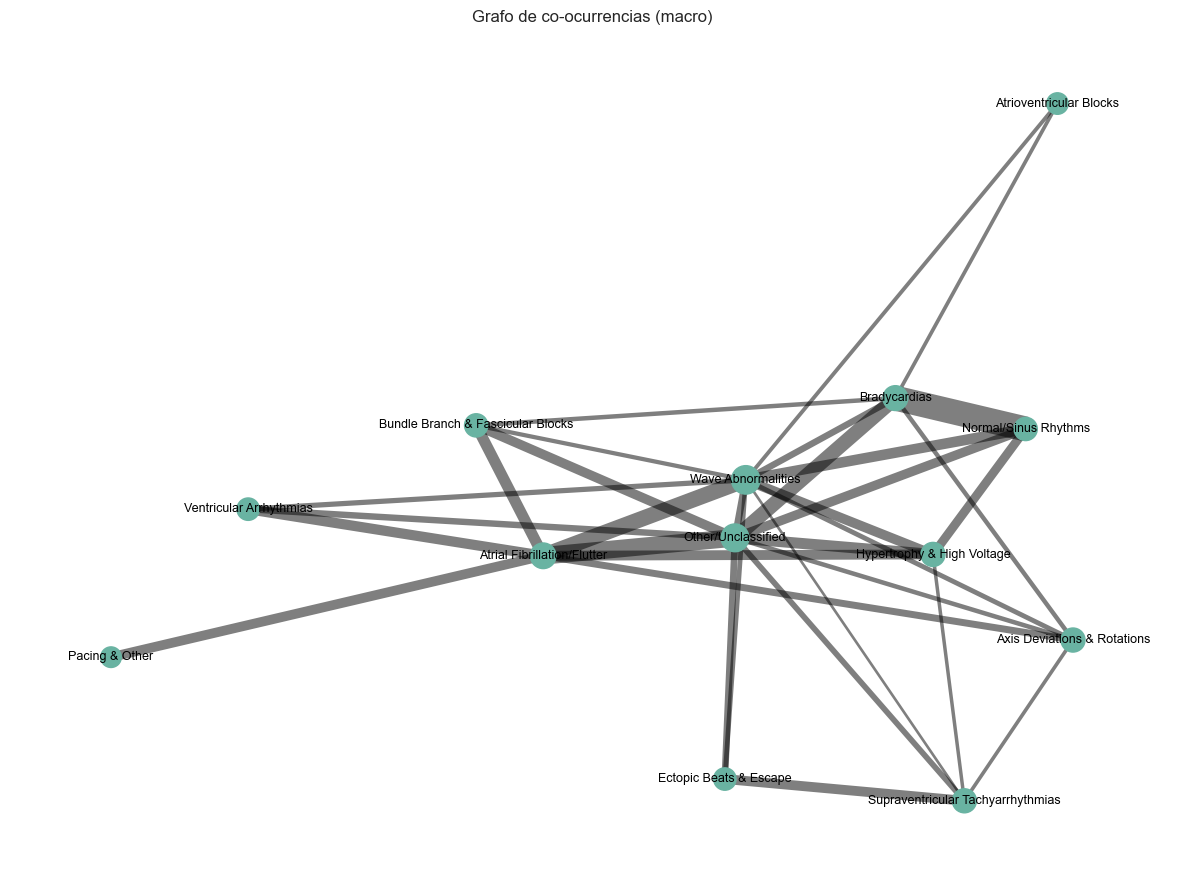

In [56]:
# --- E. Grafo de co-ocurrencias (macro) con networkx ---
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Asegura cooc_macro disponible; si no, lo recomputa rápido
if 'cooc_macro' not in globals():
    # Requiere df_merged y función cooc_table; intenta reconstruir mínimo
    if 'df_merged' not in globals():
        # Reconstrucción mínima (asume df, df_symbologia y get_macro ya definidos)
        df_ecg_exploded = df.copy()
        df_ecg_exploded['labels'] = df_ecg_exploded['labels'].str.split(',')
        df_ecg_exploded = df_ecg_exploded.explode('labels')
        df_ecg_exploded['labels'] = df_ecg_exploded['labels'].str.strip().astype(str)
        df_symbologia['Snomed_CT'] = df_symbologia['Snomed_CT'].astype(str)
        df_merged = pd.merge(df_ecg_exploded, df_symbologia, left_on='labels', right_on='Snomed_CT', how='left')
        if 'get_macro' in globals():
            df_merged['macro_class'] = df_merged['Acronym Name'].apply(get_macro)
        else:
            df_merged['macro_class'] = 'Other/Unclassified'
    macro_presence = pd.crosstab(df_merged['hea_path'], df_merged['macro_class']).clip(upper=1)

    if 'cooc_table' not in globals():
        from scipy.stats import chi2_contingency
        def cooc_table(presence_df, min_support=200):
            cols = presence_df.columns
            n = presence_df.shape[0]
            results = []
            col_sum = presence_df.sum(axis=0)
            for i, a in enumerate(cols):
                vec_a = presence_df[a].values
                for b in cols[i+1:]:
                    vec_b = presence_df[b].values
                    both = int(np.sum((vec_a==1) & (vec_b==1)))
                    if both < min_support:
                        continue
                    only_a = int(col_sum[a] - both)
                    only_b = int(col_sum[b] - both)
                    neither = int(n - (both + only_a + only_b))
                    tab = np.array([[both, only_a],[only_b, neither]])
                    try:
                        chi2, p, *_ = chi2_contingency(tab)
                    except Exception:
                        chi2, p = np.nan, np.nan
                    support = both / n
                    lift = (both / n) / ((col_sum[a]/n) * (col_sum[b]/n) + 1e-12)
                    results.append({'a':a,'b':b,'support':support,'lift':lift,'chi2':chi2,'p_value':p})
            return pd.DataFrame(results)
    cooc_macro = cooc_table(macro_presence, min_support=300)

# Filtra por p-value y soporte
thr_p = 1e-10
thr_support = 0.01

subset = cooc_macro.copy()
subset = subset.replace([np.inf, -np.inf], np.nan).dropna(subset=['p_value','support','chi2'])
subset = subset[(subset['p_value'] < thr_p) & (subset['support'] >= thr_support)]

if subset.empty:
    print("No hay co-ocurrencias que cumplan umbrales; ajusta thr_p/thr_support.")
    # Genera figura vacía igualmente
    plt.figure(figsize=(8,6))
    plt.title('Grafo de co-ocurrencias (macro) - sin aristas con umbrales actuales')
    plt.axis('off')
    plt.savefig('coocc_macro_graph.png', dpi=200)
    print("Grafo (vacío) guardado: coocc_macro_graph.png")
else:
    G = nx.Graph()
    for _, r in subset.iterrows():
        a, b = r['a'], r['b']
        w = float(r['chi2']) if pd.notna(r['chi2']) else 0.0
        G.add_edge(a, b, weight=w, support=float(r['support']), lift=float(r['lift']) if pd.notna(r['lift']) else 1.0)

    # Tamaño de nodo por grado
    deg = dict(G.degree())
    node_sizes = [200 + 20*deg.get(n,0) for n in G.nodes()]

    pos = nx.spring_layout(G, k=0.6, seed=42)
    plt.figure(figsize=(12,9))
    nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color='#69b3a2')
    edges_data = list(G.edges(data=True))
    widths = [max(0.5, (edata.get('weight',1.0))**0.5/4.0) for _,_,edata in edges_data]
    nx.draw_networkx_edges(G, pos, width=widths, alpha=0.5)
    nx.draw_networkx_labels(G, pos, font_size=9)
    plt.title('Grafo de co-ocurrencias (macro)')
    plt.axis('off')
    plt.tight_layout()
    plt.savefig('coocc_macro_graph.png', dpi=200)
    print("Grafo guardado: coocc_macro_graph.png")


In [58]:
from sklearn.model_selection import cross_val_score, GroupKFold
from sklearn.metrics import make_scorer
from sklearn.multioutput import MultiOutputClassifier

# 1. Threshold tuning per-class (usa validation set)
import numpy as np

def optimal_threshold(y_true, y_prob, macro_name):
    from sklearn.metrics import precision_recall_curve
    prec, rec, thresh = precision_recall_curve(y_true, y_prob)
    if len(thresh) == 0:
        return 0.5
    f1_scores = 2 * prec * rec / (prec + rec + 1e-6)
    idx = int(np.nanargmax(f1_scores)) if np.any(np.isfinite(f1_scores)) else 0
    return float(thresh[idx])

# Para cada modelo, ajusta en train/val
strata_train = strata.loc[X_train.index] if 'strata' in globals() else None
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, Y_train, test_size=0.2,
    stratify=strata_train if strata_train is not None else None,
    random_state=17
)
thresh_dict = {}
for col in Y.columns:
    y_prob_val = models[col].predict_proba(X_val)[:,1]
    thresh_dict[col] = optimal_threshold(y_val[col], y_prob_val, col)
    y_pred_opt = (models[col].predict_proba(X_test)[:,1] >= thresh_dict[col]).astype(int)
    f1_opt = f1_score(Y_test[col], y_pred_opt) if Y_test[col].nunique()>1 else np.nan
    base_f1 = metrics_df.loc[metrics_df['macro']==col, 'F1'].values
    base_f1 = float(base_f1[0]) if len(base_f1)>0 else np.nan
    print(f"{col}: F1 opt = {f1_opt:.3f} (vs 0.5: {base_f1:.3f})")

# 2. Cross-Validation (GroupKFold por patient_id para no leak)
patient_groups = XY['hea_path'].str.extract(r'JS(\d+)')[0].fillna(0).astype(int)  # Extrae ID paciente
gkf = GroupKFold(n_splits=5)
multi_clf = MultiOutputClassifier(XGBClassifier(**clf.get_params()))  # Mismo params
cv_scores = cross_val_score(multi_clf, X, Y, cv=gkf, groups=patient_groups, scoring='f1_macro')
print("CV F1-macro mean:", cv_scores.mean(), "+/-", cv_scores.std())

# 3. Agrega features ECG básicas (e.g., mean RR si tienes peaks)
# De tu estimate_hr, guarda rr_mediana como feature extra

Atrial Fibrillation/Flutter: F1 opt = 0.654 (vs 0.5: 0.647)
Atrioventricular Blocks: F1 opt = 0.215 (vs 0.5: 0.182)
Axis Deviations & Rotations: F1 opt = 0.252 (vs 0.5: 0.251)
Bradycardias: F1 opt = 0.702 (vs 0.5: 0.702)
Bundle Branch & Fascicular Blocks: F1 opt = 0.295 (vs 0.5: 0.289)
Ectopic Beats & Escape: F1 opt = 0.229 (vs 0.5: 0.184)
Hypertrophy & High Voltage: F1 opt = 0.431 (vs 0.5: 0.430)
Interval Abnormalities: F1 opt = 0.118 (vs 0.5: 0.079)
Low Voltage & Other Non-Specific: F1 opt = 0.160 (vs 0.5: 0.119)
Myocardial Infarction: F1 opt = 0.236 (vs 0.5: 0.063)
Normal/Sinus Rhythms: F1 opt = 0.478 (vs 0.5: 0.464)
Other/Unclassified: F1 opt = 0.493 (vs 0.5: 0.494)
Pacing & Other: F1 opt = 0.172 (vs 0.5: 0.151)
Supraventricular Tachyarrhythmias: F1 opt = 0.760 (vs 0.5: 0.723)
Ventricular Arrhythmias: F1 opt = 0.217 (vs 0.5: 0.188)
Wave Abnormalities: F1 opt = 0.596 (vs 0.5: 0.569)
CV F1-macro mean: 0.21757633780232358 +/- 0.000652899051350946


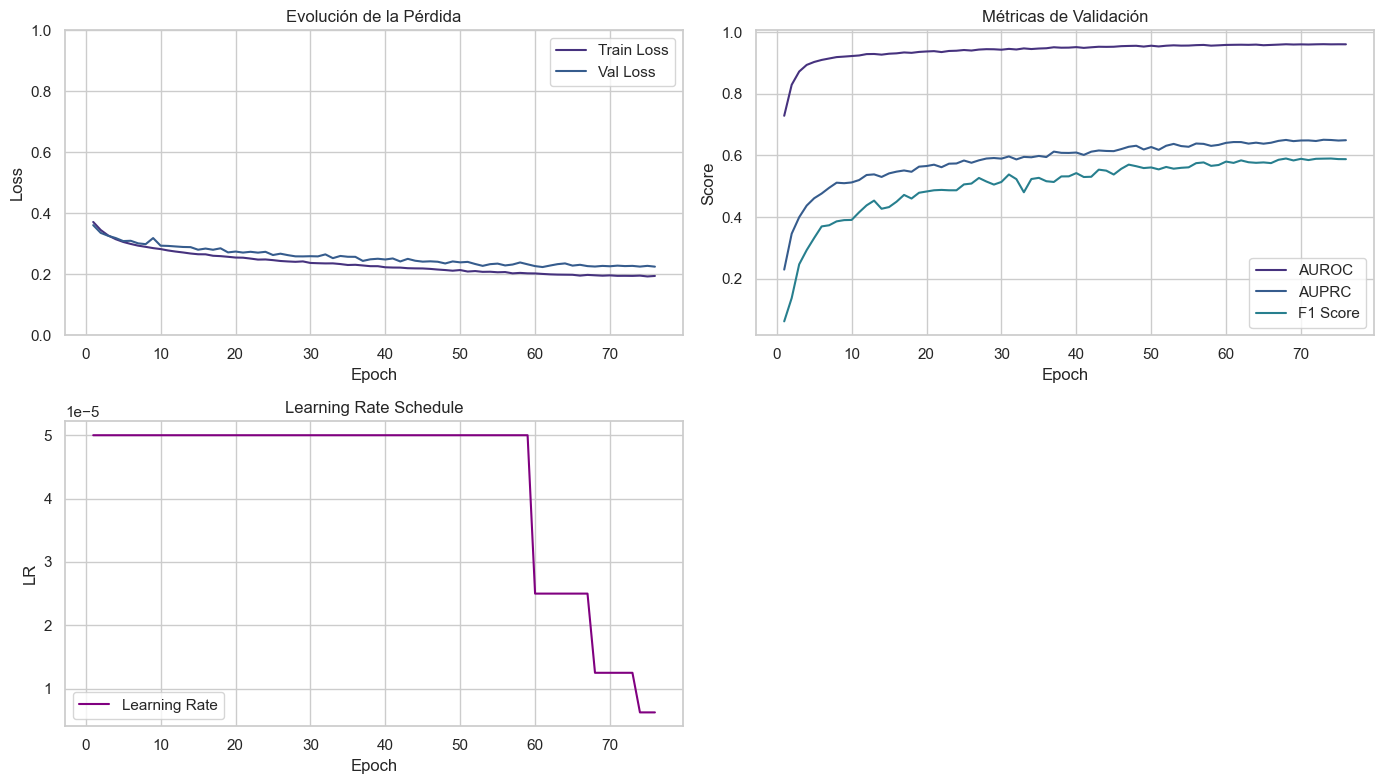

In [65]:
import pandas as pd
import matplotlib.pyplot as plt

# Datos como CSV en un string


# Leer datos
df = pd.read_csv("""C:\\Users\\pevv2\\OneDrive\\Documentos\\TESIS\\2_Modleo_AtencionPrimero\\experiments_logs\\full_run_v3_20250925_184035\\train_log.csv""")

# Crear gráficos
plt.figure(figsize=(14, 8))

# Pérdidas
plt.subplot(2, 2, 1)
plt.plot(df["epoch"], df["train_loss"], label="Train Loss",scaley=True)
plt.plot(df["epoch"], df["val_loss"], label="Val Loss",scaley=True)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Evolución de la Pérdida")
plt.ylim(0, 1)
plt.legend()

# Métricas de validación
plt.subplot(2, 2, 2)
plt.plot(df["epoch"], df["val_auroc_macro"], label="AUROC")
plt.plot(df["epoch"], df["val_auprc_macro"], label="AUPRC")
plt.plot(df["epoch"], df["val_f1_macro"], label="F1 Score")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Métricas de Validación")
plt.legend()

# Learning Rate
plt.subplot(2, 2, 3)
plt.plot(df["epoch"], df["lr"], label="Learning Rate", color="purple")
plt.xlabel("Epoch")
plt.ylabel("LR")
plt.title("Learning Rate Schedule")
plt.legend()

plt.tight_layout()
plt.show()


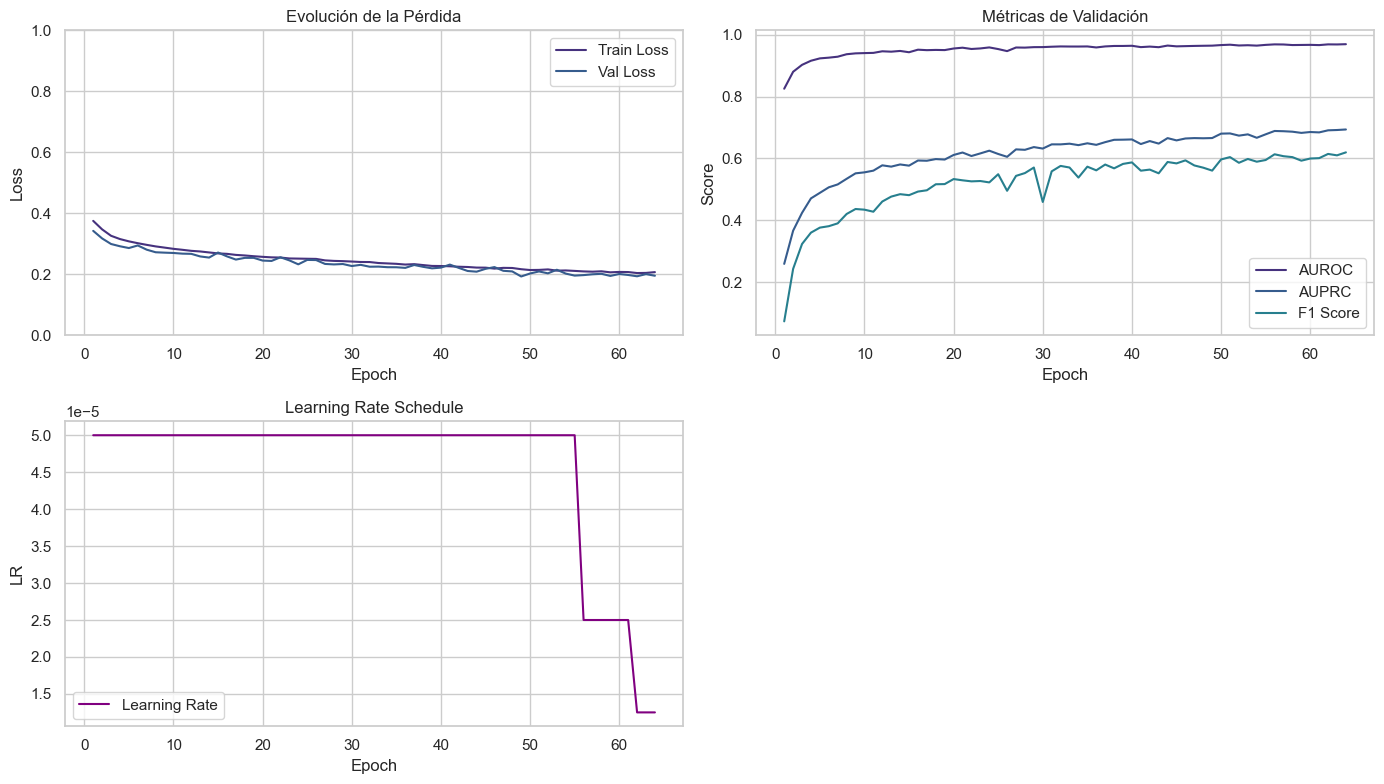

In [73]:
import pandas as pd
import matplotlib.pyplot as plt

# Datos como CSV en un string

# Leer datos
df = pd.read_csv("""C:\\Users\\pevv2\\OneDrive\\Documentos\\TESIS\\2_Modleo_AtencionPrimero\\experiments_logs\\multi_run_v3_20250926_003016\\seed_123\\train_log.csv""")

# Crear gráficos
plt.figure(figsize=(14, 8))

# Pérdidas
plt.subplot(2, 2, 1)
plt.plot(df["epoch"], df["train_loss"], label="Train Loss",scaley=True)
plt.plot(df["epoch"], df["val_loss"], label="Val Loss",scaley=True)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Evolución de la Pérdida")
plt.ylim(0, 1)
plt.legend()

# Métricas de validación
plt.subplot(2, 2, 2)
plt.plot(df["epoch"], df["val_auroc_macro"], label="AUROC")
plt.plot(df["epoch"], df["val_auprc_macro"], label="AUPRC")
plt.plot(df["epoch"], df["val_f1_macro"], label="F1 Score")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Métricas de Validación")
plt.legend()

# Learning Rate
plt.subplot(2, 2, 3)
plt.plot(df["epoch"], df["lr"], label="Learning Rate", color="purple")
plt.xlabel("Epoch")
plt.ylabel("LR")
plt.title("Learning Rate Schedule")
plt.legend()

plt.tight_layout()
plt.show()


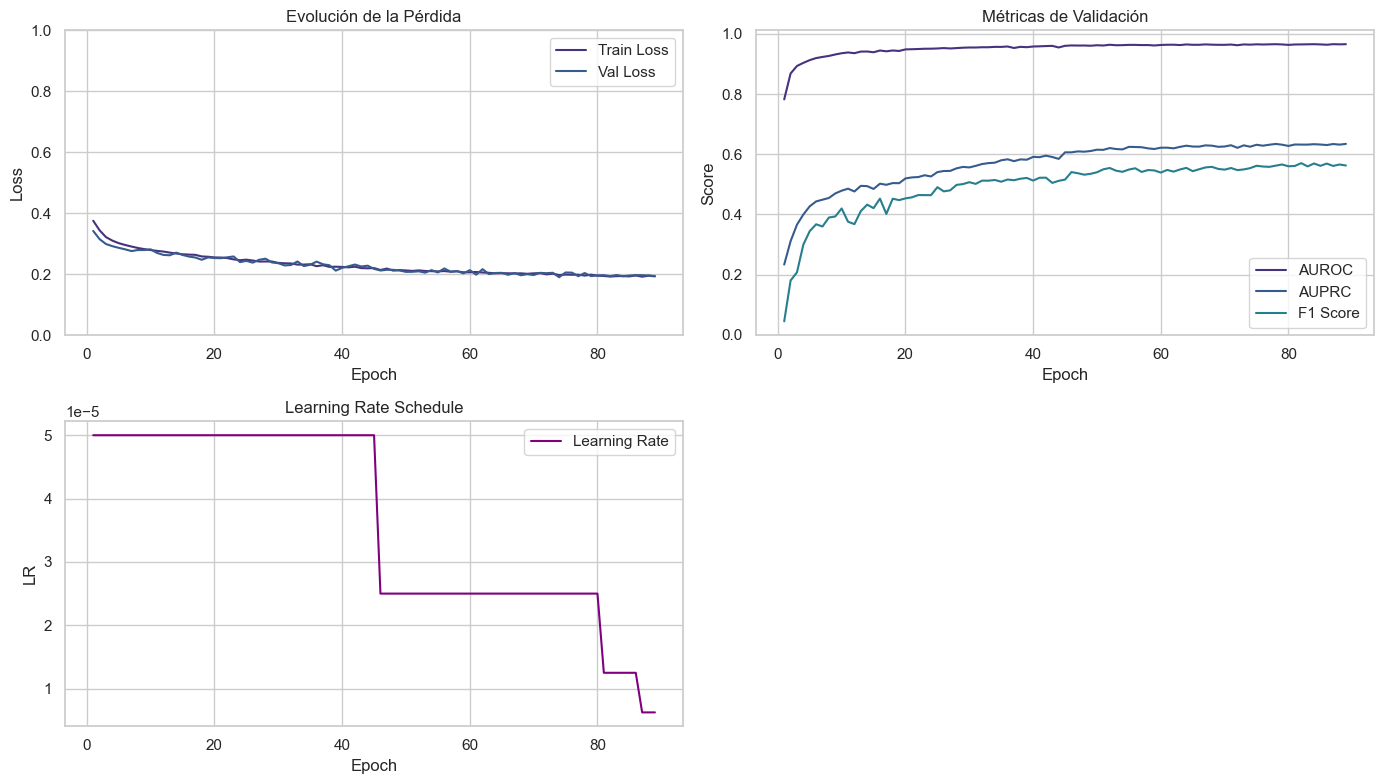

In [74]:
import pandas as pd
import matplotlib.pyplot as plt

# Datos como CSV en un string

# Leer datos
df = pd.read_csv("""C:\\Users\\pevv2\\OneDrive\\Documentos\\TESIS\\2_Modleo_AtencionPrimero\\experiments_logs\\multi_run_v3_20250926_003016\\seed_456\\train_log.csv""")

# Crear gráficos
plt.figure(figsize=(14, 8))

# Pérdidas
plt.subplot(2, 2, 1)
plt.plot(df["epoch"], df["train_loss"], label="Train Loss",scaley=True)
plt.plot(df["epoch"], df["val_loss"], label="Val Loss",scaley=True)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Evolución de la Pérdida")
plt.ylim(0, 1)
plt.legend()

# Métricas de validación
plt.subplot(2, 2, 2)
plt.plot(df["epoch"], df["val_auroc_macro"], label="AUROC")
plt.plot(df["epoch"], df["val_auprc_macro"], label="AUPRC")
plt.plot(df["epoch"], df["val_f1_macro"], label="F1 Score")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Métricas de Validación")
plt.legend()

# Learning Rate
plt.subplot(2, 2, 3)
plt.plot(df["epoch"], df["lr"], label="Learning Rate", color="purple")
plt.xlabel("Epoch")
plt.ylabel("LR")
plt.title("Learning Rate Schedule")
plt.legend()

plt.tight_layout()
plt.show()


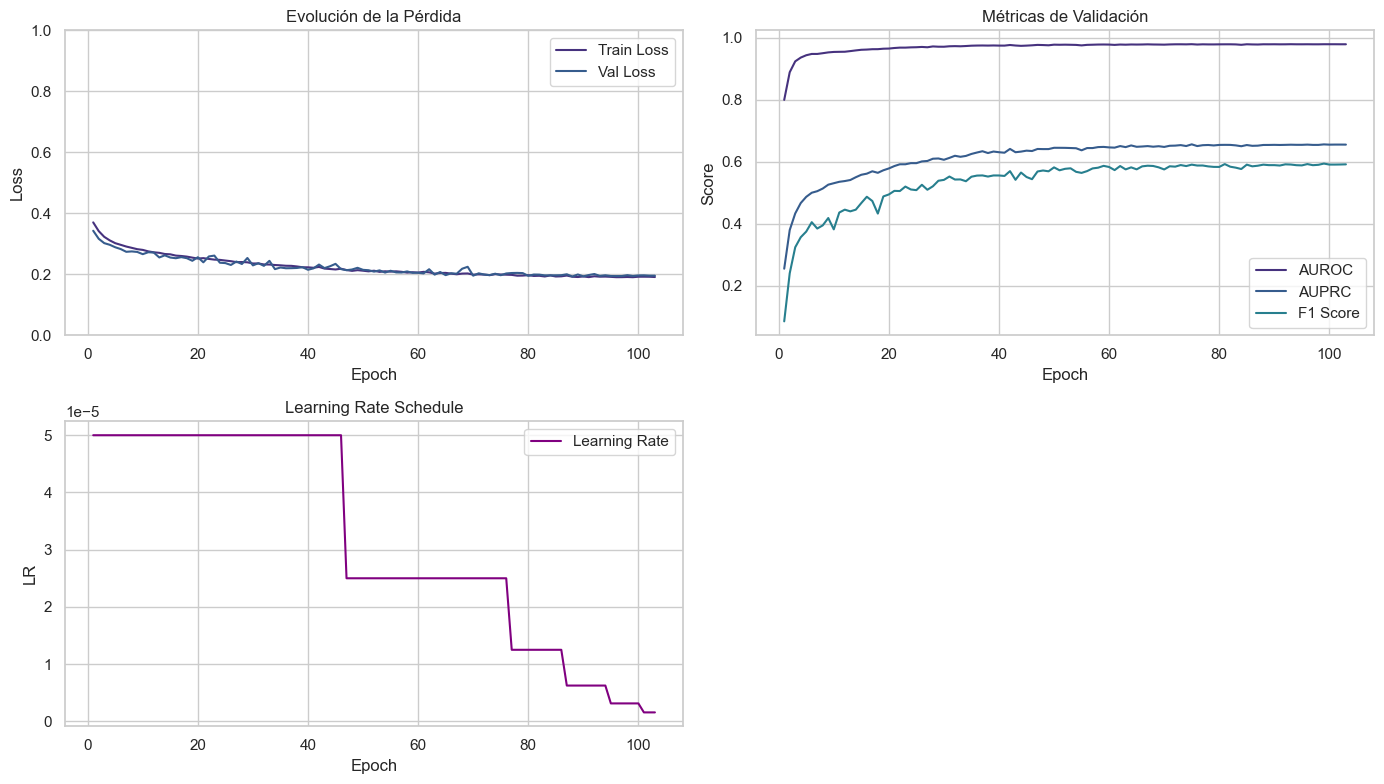

In [75]:
import pandas as pd
import matplotlib.pyplot as plt

# Datos como CSV en un string

# Leer datos
df = pd.read_csv("""C:\\Users\\pevv2\\OneDrive\\Documentos\\TESIS\\2_Modleo_AtencionPrimero\\experiments_logs\\multi_run_v3_20250926_003016\\seed_789\\train_log.csv""")

# Crear gráficos
plt.figure(figsize=(14, 8))

# Pérdidas
plt.subplot(2, 2, 1)
plt.plot(df["epoch"], df["train_loss"], label="Train Loss",scaley=True)
plt.plot(df["epoch"], df["val_loss"], label="Val Loss",scaley=True)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Evolución de la Pérdida")
plt.ylim(0, 1)
plt.legend()

# Métricas de validación
plt.subplot(2, 2, 2)
plt.plot(df["epoch"], df["val_auroc_macro"], label="AUROC")
plt.plot(df["epoch"], df["val_auprc_macro"], label="AUPRC")
plt.plot(df["epoch"], df["val_f1_macro"], label="F1 Score")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Métricas de Validación")
plt.legend()

# Learning Rate
plt.subplot(2, 2, 3)
plt.plot(df["epoch"], df["lr"], label="Learning Rate", color="purple")
plt.xlabel("Epoch")
plt.ylabel("LR")
plt.title("Learning Rate Schedule")
plt.legend()

plt.tight_layout()
plt.show()


In [76]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns


def _to_numpy(x):
    if isinstance(x, torch.Tensor):
        x = x.detach().cpu().numpy()
    return np.asarray(x)

In [77]:
def plot_snomed_bar(snomed_embed, coarse_names=None, normalize=True, sort=True, figsize=(6, 4), color='tab:red', title='Embedding SNOMED (coarse)'):
    """
    Grafica un vector snomed_embed como barras horizontales.

    snomed_embed: array-like [num_coarse] o [1, num_coarse]
    coarse_names: lista de nombres de clases coarse (len == num_coarse)
    """
    vals = _to_numpy(snomed_embed).squeeze()
    if vals.ndim != 1:
        raise ValueError('snomed_embed debe ser un vector 1D o [1, C].')
    if normalize and vals.sum() > 0:
        vals = vals / vals.sum()
    labels = np.array(coarse_names) if coarse_names is not None else np.array([f'C{i}' for i in range(len(vals))])
    order = np.argsort(vals) if sort else np.arange(len(vals))
    plt.figure(figsize=figsize)
    plt.barh(labels[order], vals[order], color=color)
    plt.xlabel('Peso')
    plt.title(title)
    plt.tight_layout()
    return plt.gca()